# 1.	Banking Customer Data Cleaning & Quality Analysis 
# a. Detect NULL values 

In [6]:
import pandas as pd
csv_3 = pd.read_csv("C:\\Users\\Pritish Manna\\Desktop\\Banking_project\\indian_bank_customers_10000_enhanced.csv")
print("Number of rows:", csv_3.shape[0])
df=csv_3.isnull().sum()
print(df)


Number of rows: 10200
Client ID                     0
Name                          0
Age                           0
State                         0
City                          0
Location ID                   0
Joined Bank                   0
Banking Contact               0
Nationality                   0
Occupation                  509
Fee Structure                 0
Loyalty Classification        0
Estimated Income            509
Superannuation Savings        0
Amount of Credit Cards        0
Credit Card Balance         514
Bank Loans                    0
Bank Deposits                 0
Checking Accounts             0
Saving Accounts               0
Foreign Currency Account      0
Business Lending            507
Properties Owned              0
Risk Weighting                0
BRId                          0
GenderId                      0
IAId                          0
dtype: int64


# b.Handle missing income, occupation ,Credit Card Balance and Business Lending

In [8]:
csv_3["Estimated Income"] = csv_3["Estimated Income"].fillna(
    csv_3["Estimated Income"].median()
)

csv_3["Occupation"] = csv_3["Occupation"].fillna(
    csv_3["Occupation"].mode()[0]
)

csv_3["Credit Card Balance"] = csv_3["Credit Card Balance"].fillna(
    csv_3["Credit Card Balance"].median()
)

csv_3["Business Lending"] = csv_3["Business Lending"].fillna(
    csv_3["Business Lending"].median()
)

# Save as a NEW file
csv_3.to_csv("clean_bank_customers.csv", index=False)

print("New cleaned CSV file created successfully!")

# Verify that no missing values remain
print("\nMissing values after cleaning:")
print(csv_3[[
    "Estimated Income",
    "Occupation",
    "Credit Card Balance",
    "Business Lending"
]].isnull().sum())

New cleaned CSV file created successfully!

Missing values after cleaning:
Estimated Income       0
Occupation             0
Credit Card Balance    0
Business Lending       0
dtype: int64


# c.	Remove duplicate rows 

In [5]:
import pandas as pd
csv_3 = pd.read_csv("C:\\Users\\Pritish Manna\\Desktop\\clean_bank_customers.csv")
print("number of duplicate row:",csv_3.duplicated().sum())
csv_3 = csv_3.drop_duplicates()
csv_3.to_csv("C:\\Users\\Pritish Manna\\Desktop\\clean_bank_customers.csv",index=False)
print("File updated successfully")



number of duplicate row: 200
File updated successfully


# d.	Validate age & financial ranges 

In [6]:
csv_3 = csv_3[
    (csv_3["Age"] >= 18) &
    (csv_3["Age"] <= 100) &
    (csv_3["Estimated Income"] >= 0) &
    (csv_3["Credit Card Balance"] >= 0) &
    (csv_3["Bank Loans"] >= 0) &
    (csv_3["Bank Deposits"] >= 0) &
    (csv_3["Checking Accounts"] >= 0) &
    (csv_3["Saving Accounts"] >= 0) &
    (csv_3["Foreign Currency Account"] >= 0) &
    (csv_3["Business Lending"] >= 0) &
    (csv_3["Superannuation Savings"] >= 0) &
    (csv_3["Amount of Credit Cards"] >= 0) &
    (csv_3["Amount of Credit Cards"] <= 10) &
    (csv_3["Properties Owned"] >= 0)
]
csv_3.to_csv("C:\\Users\\Pritish Manna\\Desktop\\clean_bank_customers.csv",index=False)
print("Cleaned CSV file has been updated successfully.")


Cleaned CSV file has been updated successfully.


# 2.  Customer Segmentation Analysis 
# a. Group by 
# •	Loyalty Classification 

In [8]:
loyalty_group = csv_3.groupby("Loyalty Classification").size().reset_index(name="Customers")
print(loyalty_group)


  Loyalty Classification  Customers
0                   Gold       2608
1                   Jade       2551
2               Platinum       2443
3                 Silver       2398


# •	Risk Weighting 

In [9]:
risk_group = csv_3.groupby("Risk Weighting").size().reset_index(name="Customers")
print(risk_group)


   Risk Weighting  Customers
0               1       2000
1               2       2000
2               3       2000
3               4       2000
4               5       2000


# •	Gender 

In [11]:
gender_group = (
    csv_3.groupby("GenderId")
    .size()
    .reset_index(name="Customers")
)

gender_group["Gender"] = gender_group["GenderId"].map({
    1: "Male",
    2: "Female"
})

# Rearrange the columns
gender_group = gender_group[["GenderId", "Gender", "Customers"]]

print(gender_group)

   GenderId  Gender  Customers
0         1    Male       5000
1         2  Female       5000


# •	State 

In [12]:
state_group = csv_3.groupby("State").size().reset_index(name="Customers")
print(state_group)


         State  Customers
0        Delhi       1438
1      Gujarat       1422
2    Karnataka       1480
3  Maharashtra       1440
4   Tamil Nadu       1413
5    Telangana       1416
6  West Bengal       1391


# b. Identify 
# High-Value Customers 

In [13]:
high_value = csv_3[
    (csv_3["Estimated Income"] >= 950728) &
    (csv_3["Bank Deposits"] >= 6067405) &
    (csv_3["Saving Accounts"] >= 2985411) &
    (csv_3["Loyalty Classification"].isin(["Gold", "Platinum"]))
]

print("Number of High-Value Customers:", len(high_value))
print("\nHigh-Value Customer Names:")
print(high_value["Name"])


Number of High-Value Customers: 84

High-Value Customer Names:
333       Neha Patel
619       Ritu Verma
1090    Ramesh Verma
1111     Pooja Gupta
1209     Sneha Kumar
            ...     
9746     Ankit Gupta
9806     Vikas Mehta
9838      Rahul Iyer
9867     Asha Sharma
9928     Ankit Gupta
Name: Name, Length: 84, dtype: str


# Risky Customers (Here we Treat customers with Risk Weighting 4 or 5 as risky).

In [14]:
risky_customers = csv_3[csv_3["Risk Weighting"] >= 4]
print("Number of Risky Customers:", len(risky_customers))
print(risky_customers["Name"])


Number of Risky Customers: 4000
3       Sneha Sharma
4        Kunal Mehta
8        Arjun Patel
9         Anjali Das
13       Nisha Singh
            ...     
9989    Kavita Patel
9993     Sneha Patel
9994     Rohit Verma
9998       Amit Iyer
9999    Anjali Singh
Name: Name, Length: 4000, dtype: str


# Low-profit customers 

In [15]:
low_profit = csv_3[
    (csv_3["Estimated Income"] < 500000) &
    (csv_3["Bank Deposits"] < 2000000) &
    (csv_3["Bank Loans"] > 3000000)
]
print("Number of Low-Profit Customers:", len(low_profit))
print(low_profit["Name"])


Number of Low-Profit Customers: 212
2          Amit Patel
80       Suresh Reddy
89          Ritu Iyer
166        Amit Gupta
245        Ritu Verma
            ...      
9744       Arjun Iyer
9811     Priya Sharma
9831        Asha Iyer
9930    Suresh Sharma
9951     Anjali Patel
Name: Name, Length: 212, dtype: str


# c. Visuals
# Bar Charts 
# Customers by Loyalty Classification

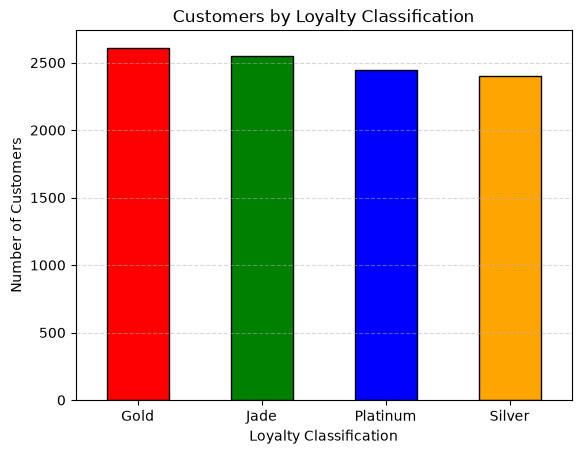

In [16]:
import matplotlib.pyplot as plt
colors = ["red", "green", "blue", "orange", "purple"]
csv_3["Loyalty Classification"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)
plt.title("Customers by Loyalty Classification")
plt.xlabel("Loyalty Classification")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


# Customers by State

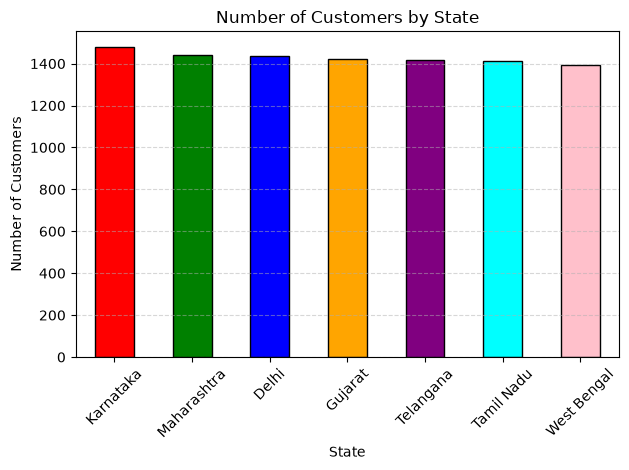

In [17]:
colors =  [
    "red", "green", "blue", "orange", "purple",
    "cyan", "pink", "gold", "brown", "gray"
]
csv_3["State"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)
plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Average Estimated Income by State 

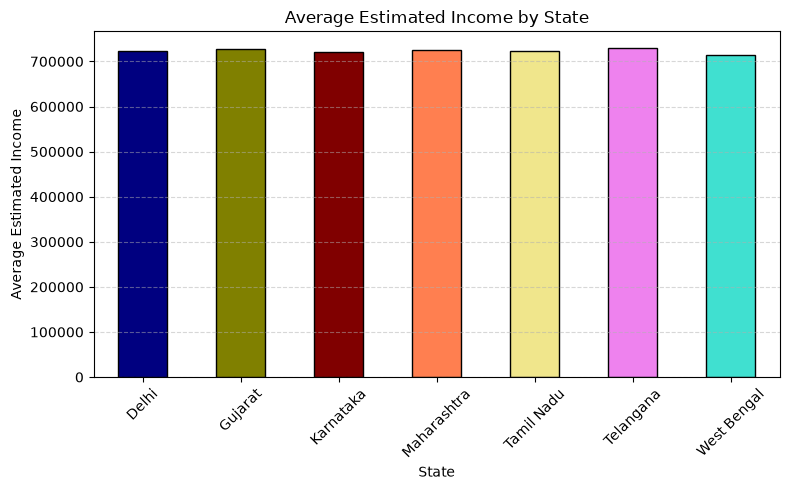

In [18]:
colors = [
    "navy", "olive","maroon", "coral", "khaki", "violet", "turquoise"
]

plt.figure(figsize=(8,5))
csv_3.groupby("State")["Estimated Income"].mean().plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)
plt.title("Average Estimated Income by State")
plt.xlabel("State")
plt.ylabel("Average Estimated Income")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Box plots 
# Box Plot of Estimated Income

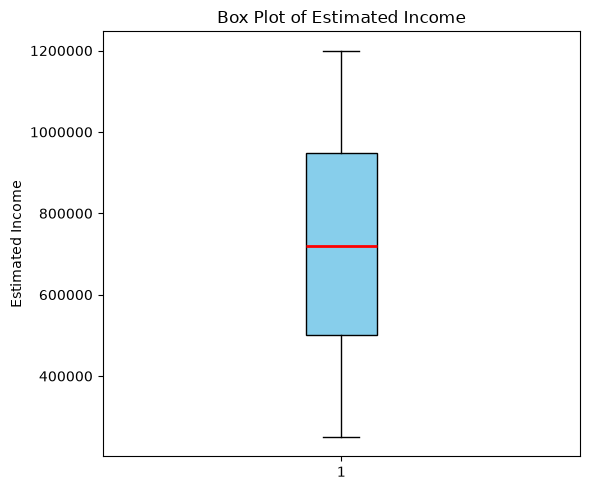

In [19]:
plt.figure(figsize=(6,5))

plt.boxplot(
    csv_3["Estimated Income"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="black"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Box Plot of Estimated Income")
plt.ylabel("Estimated Income")
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


# Box Plot of Bank Deposits 

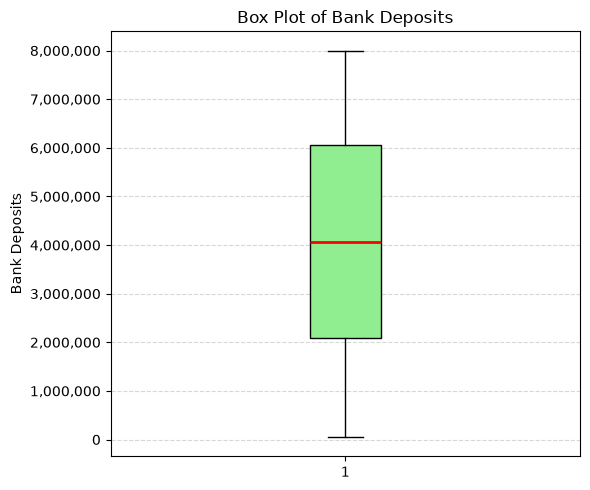

In [23]:
import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))

plt.boxplot(
    csv_3["Bank Deposits"],
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen", edgecolor="black"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Box Plot of Bank Deposits")
plt.ylabel("Bank Deposits")
plt.xticks([1])

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# State-wise income heatmaps 

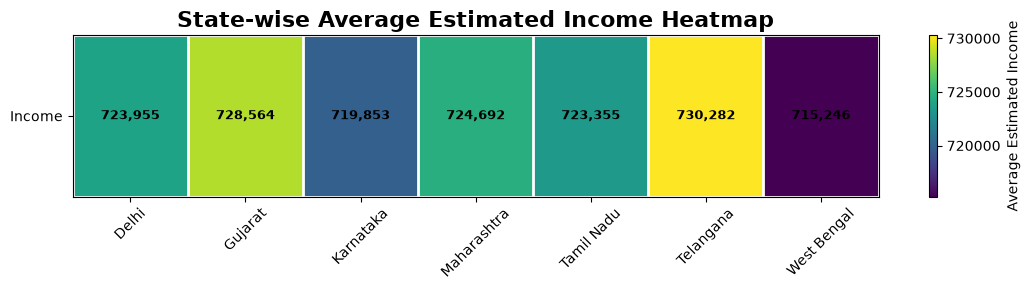

In [25]:
import numpy as np
state_income = csv_3.groupby("State")["Estimated Income"].mean()
data = np.array([state_income.values])
plt.figure(figsize=(11, 3))
plt.imshow(data, cmap="viridis", aspect="auto")
plt.colorbar(label="Average Estimated Income")
plt.xticks(
    range(len(state_income.index)),
    state_income.index,
    rotation=45,
    fontsize=10
)
plt.yticks([0], ["Income"], fontsize=10)
for i, value in enumerate(state_income.values):
    plt.text(
        i,
        0,
        f"{value:,.0f}",
        ha="center",
        va="center",
        color="black",
        fontsize=9,
        fontweight="bold"
    )
ax = plt.gca()
ax.set_xticks(np.arange(-0.5, len(state_income), 1), minor=True)
ax.set_yticks(np.arange(-0.5, 1.5, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
plt.title(
    "State-wise Average Estimated Income Heatmap",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


# 3. Credit Risk Analysis Project 
# a.  Compare 
# •	Bank Loans vs Income 


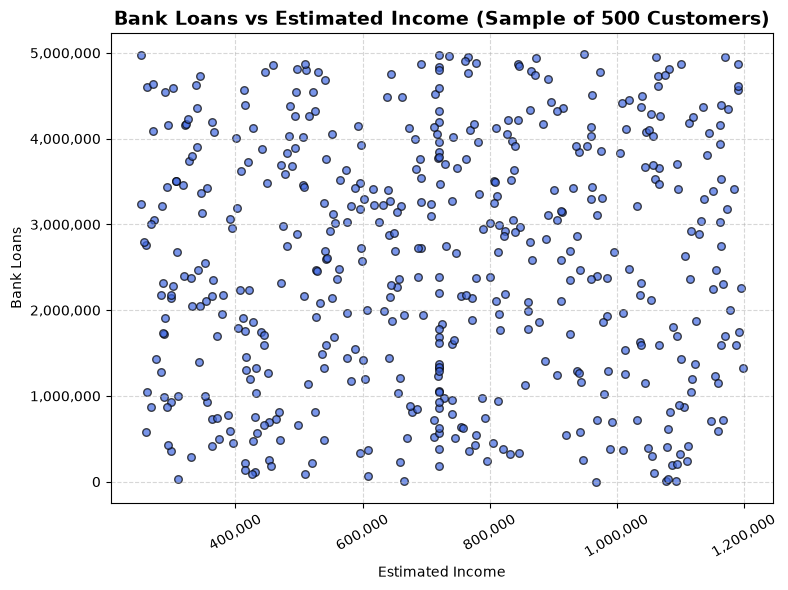

In [26]:
sample = csv_3.sample(n=500, random_state=42)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["Estimated Income"],
    sample["Bank Loans"],
    color="royalblue",
    s=30,
    alpha=0.7,
    edgecolors="black"
)

plt.title("Bank Loans vs Estimated Income (Sample of 500 Customers)",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Estimated Income")
plt.ylabel("Bank Loans")

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# •	Credit Card Balance vs Risk Weighting 

<Figure size 700x500 with 0 Axes>

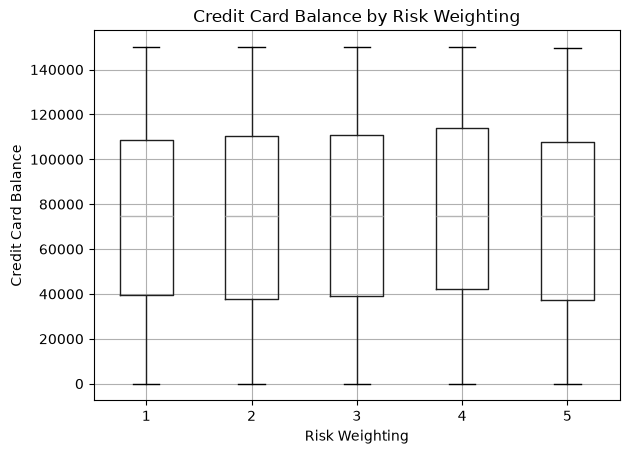

In [27]:
plt.figure(figsize=(7,5))
csv_3.boxplot(column="Credit Card Balance", by="Risk Weighting")

plt.title("Credit Card Balance by Risk Weighting")
plt.suptitle("")
plt.xlabel("Risk Weighting")
plt.ylabel("Credit Card Balance")
plt.tight_layout()
plt.show()


# b.  Identify red flags
# High loans + low income

In [29]:
high_loan_low_income = csv_3[
    (csv_3["Estimated Income"] < 500000) &
    (csv_3["Bank Loans"] > 3000000)
]

print("Number of High Loan + Low Income Customers:", len(high_loan_low_income))
print(high_loan_low_income)


Number of High Loan + Low Income Customers: 994
     Client ID           Name  Age        State       City  Location ID  \
2     IND10002     Amit Patel   22      Gujarat      Surat        31512   
14    IND10014    Ankit Gupta   25    Telangana   Warangal        98154   
40    IND10040     Ankit Iyer   45        Delhi  New Delhi        95203   
44    IND10044   Arjun Sharma   45  West Bengal     Howrah        18224   
45    IND10045     Asha Verma   50    Karnataka  Bengaluru        89647   
...        ...            ...  ...          ...        ...          ...   
9930  IND19930  Suresh Sharma   35        Delhi  New Delhi        30588   
9951  IND19951   Anjali Patel   50    Telangana  Hyderabad        23878   
9953  IND19953   Kavita Reddy   40  Maharashtra     Mumbai        62354   
9974  IND19974    Rohit Reddy   25        Delhi  New Delhi         1235   
9998  IND19998      Amit Iyer   30   Tamil Nadu    Chennai        89651   

     Joined Bank Banking Contact Nationality       

#Explanation  
Customers with an estimated income below ₹500,000 and bank loans above ₹3,000,000 were identified as potential credit risk customers. A total of 994 customers met this criterion.


# Multiple properties + high debt 

In [30]:
multiple_properties_high_debt = csv_3[
    (csv_3["Properties Owned"] >= 2) &
    (csv_3["Bank Loans"] > 3000000)
]
print("Number of Multiple Properties + High Debt Customers:", len(multiple_properties_high_debt))
print(multiple_properties_high_debt)


Number of Multiple Properties + High Debt Customers: 2673
     Client ID          Name  Age        State        City  Location ID  \
1     IND10001   Sneha Singh   50    Karnataka   Bengaluru        45118   
2     IND10002    Amit Patel   22      Gujarat       Surat        31512   
4     IND10004   Kunal Mehta   50  Maharashtra      Mumbai        15371   
13    IND10013   Nisha Singh   25    Telangana   Hyderabad        35664   
21    IND10021     Asha Iyer   50  West Bengal      Howrah        59008   
...        ...           ...  ...          ...         ...          ...   
9981  IND19981   Pooja Mehta   30   Tamil Nadu     Madurai        40277   
9990  IND19990   Rahul Reddy   30      Gujarat    Vadodara        47989   
9992  IND19992  Ramesh Kumar   45   Tamil Nadu  Coimbatore        17928   
9993  IND19993   Sneha Patel   35      Gujarat    Vadodara        48671   
9995  IND19995    Asha Mehta   30  West Bengal     Kolkata        95784   

     Joined Bank Banking Contact National

#In this analysis, a customer is considered Multiple Properties + High Debt if they own two or more properties (Properties Owned >= 2) and have bank loans greater than ₹3,000,000 (Bank Loans > 3,000,000). These customers may have a higher financial burden due to large outstanding loans despite owning multiple properties. Therefore, they are identified as potential credit risk customers for further analysis.

# 4. State & City-wise Banking Performance Dashboard 
# State wise (Deposits, loans, Business Lending)
# City-Wise (Customer count, Avg income)


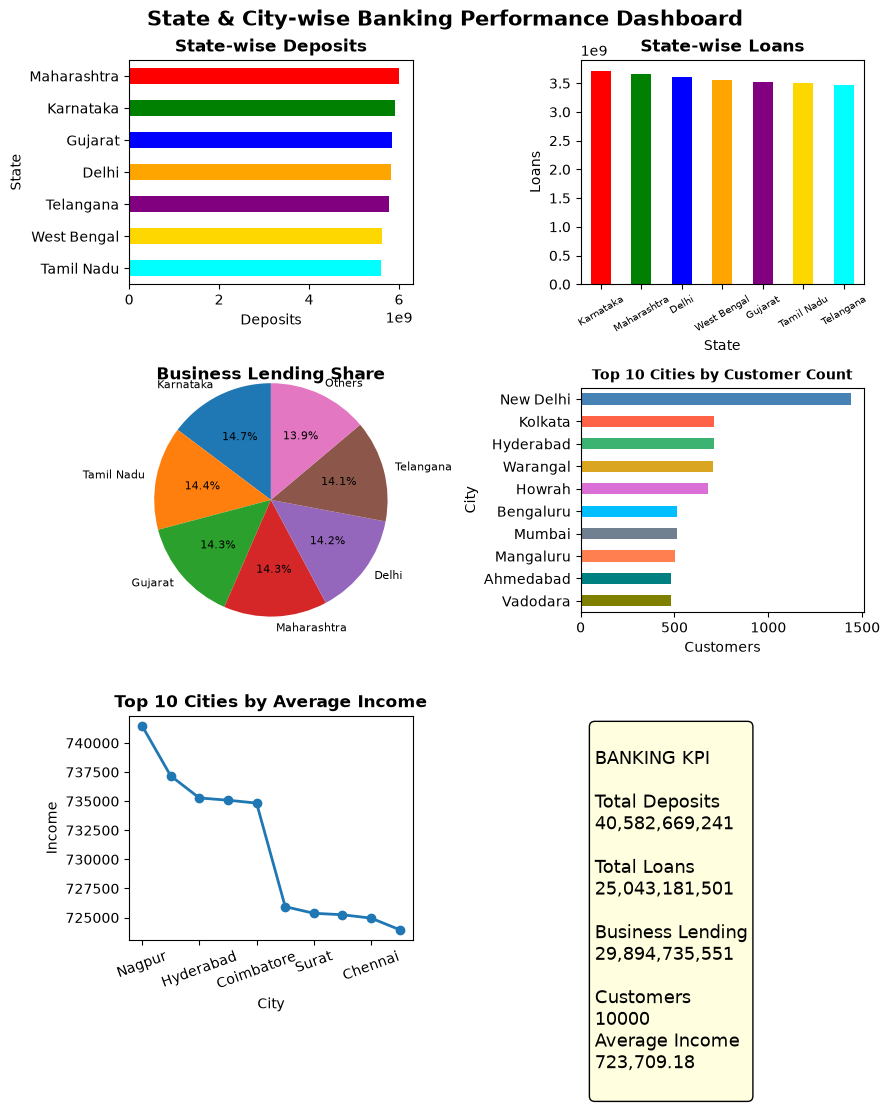

In [31]:
total_deposit = csv_3["Bank Deposits"].sum()
total_loan = csv_3["Bank Loans"].sum()
total_business = csv_3["Business Lending"].sum()
total_customer = csv_3["Client ID"].nunique()
avg_income = csv_3["Estimated Income"].mean()

state_deposit = csv_3.groupby("State")["Bank Deposits"].sum().sort_values(ascending=False)

state_loan = csv_3.groupby("State")["Bank Loans"].sum().sort_values(ascending=False)

state_business = csv_3.groupby("State")["Business Lending"].sum().sort_values(ascending=False)

city_customer = csv_3.groupby("City")["Client ID"].count().sort_values(ascending=False).head(10)

city_income = csv_3.groupby("City")["Estimated Income"].mean().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(9,11))
fig.suptitle(
    "State & City-wise Banking Performance Dashboard",
    fontsize=15,
    fontweight="bold"
)

c = ["red", "green", "blue", "orange", "purple", "gold", "cyan"]

ax1 = plt.subplot(3,2,1)
state_deposit.plot(
    kind="barh",
    ax=ax1,
    color=c
)

ax1.set_title("State-wise Deposits",fontweight="bold")
ax1.set_xlabel("Deposits")
ax1.invert_yaxis()

ax2 = plt.subplot(3,2,2)
state_loan.plot(
    kind="bar",
    color=c,
    ax=ax2,
)

ax2.set_title("State-wise Loans",fontweight="bold")
ax2.set_ylabel("Loans")
ax2.tick_params(axis="x", rotation=30,labelsize=7)
ax3 = plt.subplot(3,2,3)
top_business = state_business.head(6)
others = state_business.iloc[6:].sum()
pie_data = pd.concat(
    [top_business, pd.Series({"Others":others})]
)

ax3.pie(
    pie_data,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90,
    radius=1.3,
    textprops={"fontsize":8}

)
ax3.set_title("Business Lending Share",fontweight="bold")
ax4 = plt.subplot(3,2,4)
city_customer.plot(
    kind="barh",
    color=[
    "steelblue",
    "tomato",
    "mediumseagreen",
    "goldenrod",
    "orchid",
    "deepskyblue",
    "slategray",
    "coral",
    "teal",
    "olive"
],
    ax=ax4
)
ax4.set_title("Top 10 Cities by Customer Count",fontsize=10,fontweight="bold")
ax4.set_xlabel("Customers")
ax4.invert_yaxis()
ax5 = plt.subplot(3,2,5)
city_income.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=ax5
)
ax5.set_title("Top 10 Cities by Average Income",fontweight="bold")
ax5.set_ylabel("Income")
ax5.tick_params(axis="x", rotation=20)

ax6 = plt.subplot(3,2,6)
ax6.axis("off")

text = f"""
BANKING KPI

Total Deposits
{total_deposit:,.0f}

Total Loans
{total_loan:,.0f}

Business Lending
{total_business:,.0f}

Customers
{total_customer}
Average Income
{avg_income:,.2f}
"""
ax6.text(
    0.05,
    0.95,
    text,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        facecolor="lightyellow",
        edgecolor="black",
        boxstyle="round"
    )
)
plt.tight_layout()   
plt.show()


# 5. Bank Revenue Performance Dashboard 
#(Total Bank Deposits, Total Bank Loans, Business Lending ,Credit Card Outstanding )
Visuals
(KPI cards , Monthly trend line ,State-wise revenue bar chart ,Loan vs Deposit comparison )




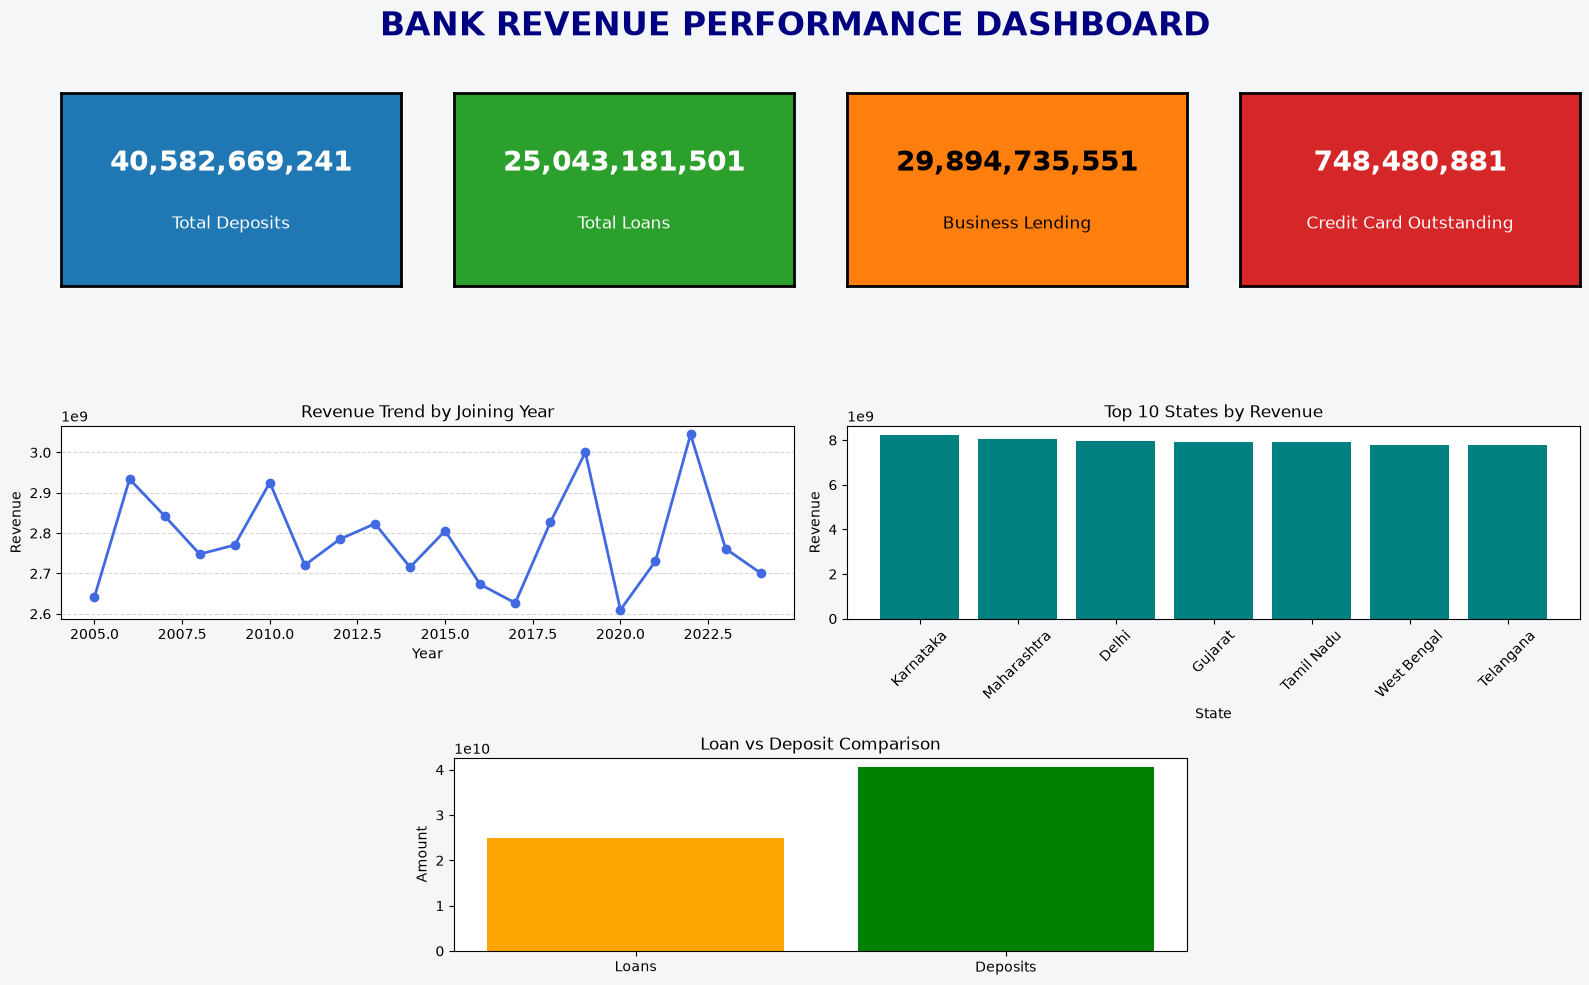

In [34]:
csv_3["Business Lending"] = csv_3["Business Lending"].fillna(0)
csv_3["Credit Card Balance"] = csv_3["Credit Card Balance"].fillna(0)
csv_3["Joined Bank"] = pd.to_datetime(
    csv_3["Joined Bank"],
    format="%d-%m-%Y",
    errors="coerce"
)
csv_3["Year"] = csv_3["Joined Bank"].dt.year
csv_3["Total Revenue"] = (
    csv_3["Bank Loans"] +
    csv_3["Business Lending"] +
    csv_3["Credit Card Balance"]
)
total_deposit = csv_3["Bank Deposits"].sum()
total_loans = csv_3["Bank Loans"].sum()
total_business = csv_3["Business Lending"].sum()
total_credit = csv_3["Credit Card Balance"].sum()
fig = plt.figure(figsize=(16,10))
ax1 = plt.subplot2grid((3,4),(0,0))
ax1.set_facecolor("#1F77B4")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.text(
    0.5,0.6,
    f"{total_deposit:,.0f}",
    fontsize=20,
    weight="bold",
    ha="center",
    color="white"
)
ax1.text(
    0.5,0.3,
    "Total Deposits",
    fontsize=12,
    ha="center",
    color="white"
)
ax2 = plt.subplot2grid((3,4),(0,1))
ax2.set_facecolor("#2CA02C") 
ax2.set_xticks([])
ax2.set_yticks([])
ax2.text(
    0.5,0.6,
    f"{total_loans:,.0f}",
    fontsize=20,
    weight="bold",
    ha="center",
    color="white"
)
ax2.text(
    0.5,0.3,
    "Total Loans",
    fontsize=12,
    ha="center",
    color="white"
)
ax3 = plt.subplot2grid((3,4),(0,2))
ax3.set_facecolor("#FF7F0E") 
ax3.set_xticks([])
ax3.set_yticks([])
ax3.text(
    0.5,0.6,
    f"{total_business:,.0f}",
    fontsize=20,
    weight="bold",
    ha="center"
)
ax3.text(
    0.5,0.3,
    "Business Lending",
    fontsize=12,
    ha="center"
)
ax4 = plt.subplot2grid((3,4),(0,3))
ax4.set_facecolor("#D62728")
ax4.set_xticks([])
ax4.set_yticks([])
ax4.text(
    0.5,0.6,
    f"{total_credit:,.0f}",
    fontsize=20,
    weight="bold",
    ha="center",
    color="white"
)
ax4.text(
    0.5,0.3,
    "Credit Card Outstanding",
    fontsize=12,
    ha="center",
    color="white"
)
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor("black")
year_revenue = (
    csv_3.groupby("Year")["Total Revenue"]
    .sum()
    .dropna()
)
ax5 = plt.subplot2grid((3,4),(1,0),colspan=2)
ax5.plot(
    year_revenue.index,
    year_revenue.values,
    color="royalblue",
    marker="o",
    linewidth=2
)
ax5.set_title("Revenue Trend by Joining Year")
ax5.set_xlabel("Year")
ax5.set_ylabel("Revenue")
ax5.grid(axis="y", linestyle="--", alpha=0.5)
state_revenue = (
    csv_3.groupby("State")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
ax6 = plt.subplot2grid((3,4),(1,2),colspan=2)
ax6.bar(
    state_revenue.index,
    state_revenue.values,
    color="teal"
)
ax6.set_title("Top 10 States by Revenue")
ax6.set_xlabel("State")
ax6.set_ylabel("Revenue")
ax6.tick_params(axis='x', rotation=45)
comparison = pd.DataFrame({
    "Amount":[
        total_loans,
        total_deposit
    ]
},
index=[
    "Loans",
    "Deposits"
])
ax7 = plt.subplot2grid((3,4),(2,1),colspan=2)
ax7.bar(
    comparison.index,
    comparison["Amount"],
    color=["orange","green"]
)
ax7.set_title("Loan vs Deposit Comparison")
ax7.set_ylabel("Amount")
fig.patch.set_facecolor("#F4F6F7")
plt.suptitle(
    "BANK REVENUE PERFORMANCE DASHBOARD",
    fontsize=24,
    fontweight="bold",
    color="navy"
)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# 6.Customer Profitability Dashboard 
#Which customers are most valuable to the bank? 
       ▪ Avg balance per customer 
       ▪ Total deposits by loyalty 
        ▪ Loan-to-income ratio 
Visuals
        ▪ Loyalty-wise profit 
        ▪ Top 10 high-value customers 
        ▪ Risk vs profitability matrix 
 

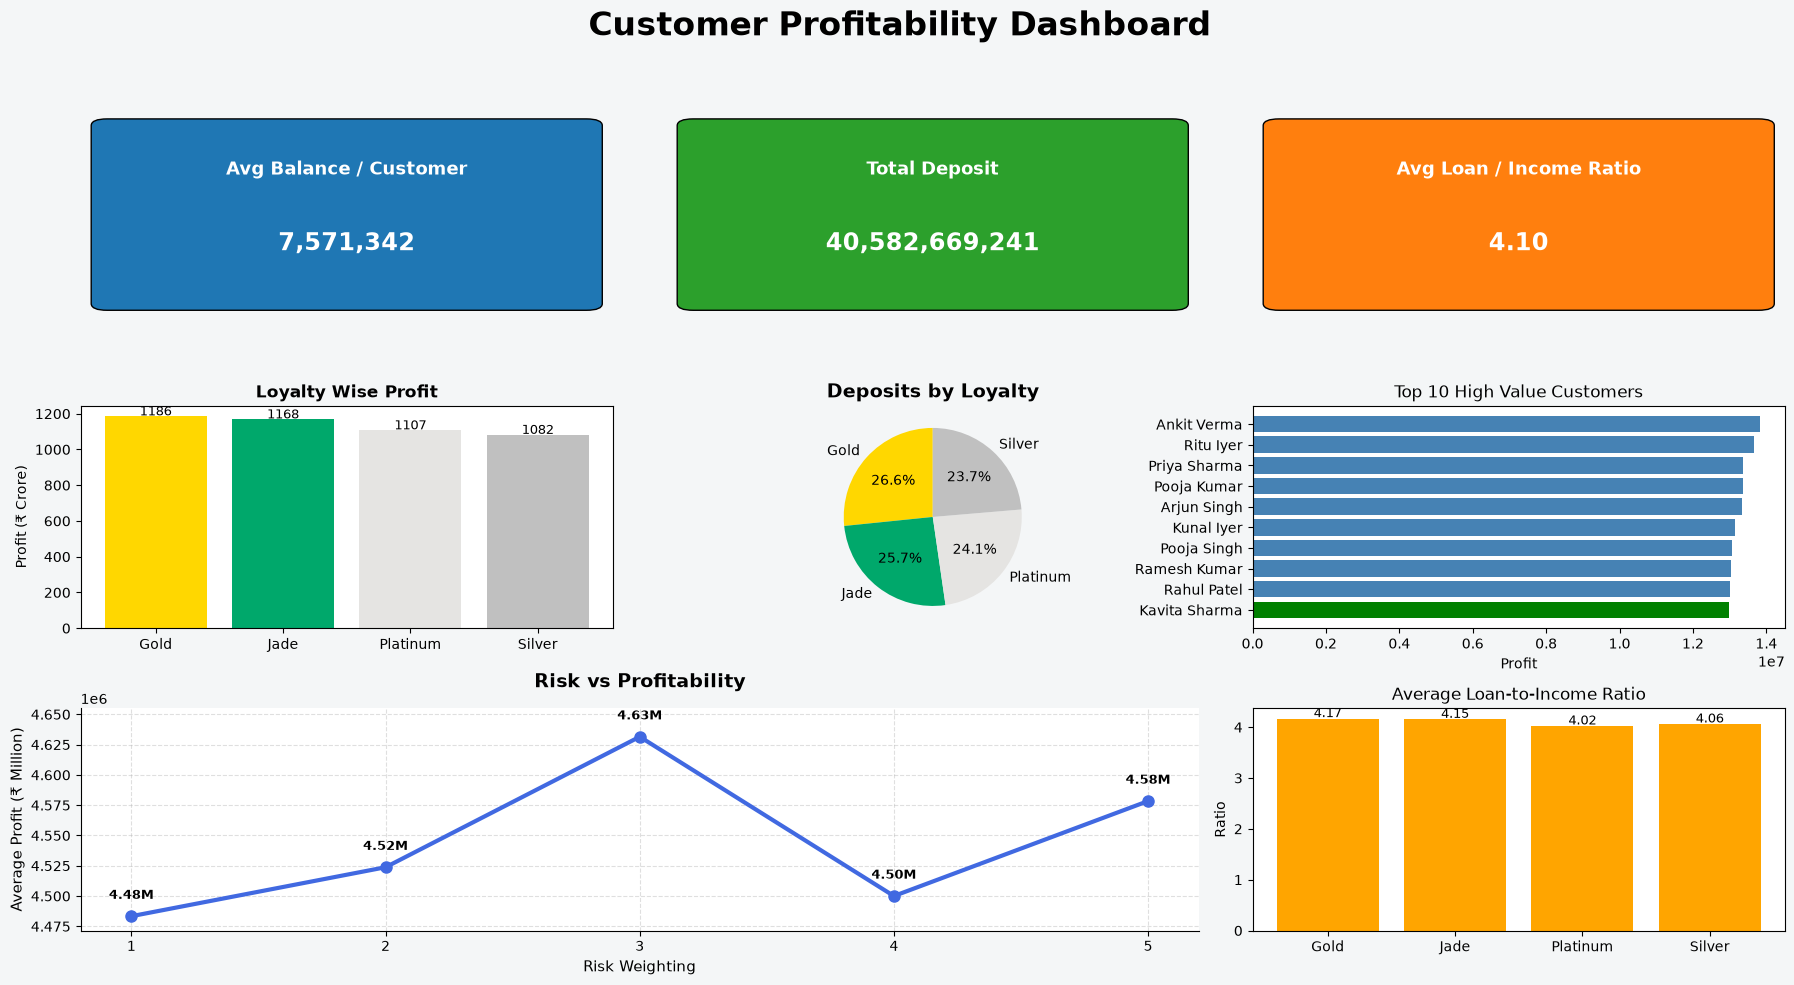

In [38]:
from matplotlib.patches import FancyBboxPatch
df = pd.read_csv("C:\\Users\\Pritish Manna\\Desktop\\clean_bank_customers.csv")
numeric_cols = [
    "Bank Deposits",
    "Saving Accounts",
    "Checking Accounts",
    "Bank Loans",
    "Estimated Income",
    "Business Lending",
    "Credit Card Balance",
    "Risk Weighting"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df["Total Balance"] = (
    df["Bank Deposits"] +
    df["Saving Accounts"] +
    df["Checking Accounts"]
)
df["Profit"] = (
    df["Bank Deposits"] +
    df["Business Lending"] -
    df["Bank Loans"]
)
df["Loan Income Ratio"] = (
    df["Bank Loans"] /
    df["Estimated Income"]
).replace([float("inf"), -float("inf")], 0)

avg_balance = df["Total Balance"].mean()
total_deposit = df.groupby("Loyalty Classification")["Bank Deposits"].sum()
loan_income_ratio = df["Loan Income Ratio"].mean()
top_customers = df.nlargest(10, "Profit")
loyalty_profit = df.groupby("Loyalty Classification")["Profit"].sum()

fig = plt.figure(figsize=(18,10), facecolor="#F4F6F7")
fig.suptitle(
    "Customer Profitability Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)
plt.subplots_adjust(
    left=0.05,
    right=0.98,
    top=0.88,
    bottom=0.06,
    hspace=0.35,
    wspace=0.25
)
def kpi(ax, title, value, color):

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.axis("off")

    box = FancyBboxPatch(
        (0.05,0.1),
        0.9,
        0.8,
        boxstyle="round,pad=0.03",
        facecolor=color
    )

    ax.add_patch(box)

    ax.text(0.5,
            0.68,
            title,
            ha='center',
            fontsize=13,
            color='white',
            weight='bold')

    ax.text(0.5,
            0.34,
            value,
            ha='center',
            fontsize=17,
            color='white',
            weight='bold')
ax1 = plt.subplot2grid((3,3),(0,0))
kpi(ax1,
    "Avg Balance / Customer",
    f"{avg_balance:,.0f}",
    "#1f77b4")
ax2 = plt.subplot2grid((3,3),(0,1))
kpi(ax2,
    "Total Deposit",
    f"{df['Bank Deposits'].sum():,.0f}",
    "#2ca02c")
ax3 = plt.subplot2grid((3,3),(0,2))
kpi(ax3,
    "Avg Loan / Income Ratio",
    f"{loan_income_ratio:.2f}",
    "#ff7f0e")
ax4 = plt.subplot2grid((3,3),(1,0))
loyalty_profit = (
    df.groupby("Loyalty Classification")["Profit"].sum()/10000000
)

ax4.bar(
    loyalty_profit.index,
    loyalty_profit.values,
    color=["#FFD700","#00A86B","#E5E4E2","#C0C0C0"]
)
for i,v in enumerate(loyalty_profit.values):
    ax4.text(i,
             v+5,
             f"{v:.0f}",
             ha='center',
             fontsize=9)
ax4.set_title("Loyalty Wise Profit",weight="bold")
ax4.set_ylabel("Profit (₹ Crore)")
ax5 = plt.subplot2grid((3,3),(1,1))
ax5.pie(
    total_deposit.values,
    labels=total_deposit.index,
    autopct='%1.1f%%',
    colors=["#FFD700", "#00A86B", "#E5E4E2", "#C0C0C0"],
    startangle=90
)
ax5.set_title("Deposits by Loyalty", fontsize=14, fontweight="bold")
ax6 = plt.subplot2grid((3,3),(1,2))
colors = ["steelblue"]*10
colors[-1] = "green"
ax6.barh(
    top_customers["Name"],
    top_customers["Profit"],
    color=colors
)
ax6.set_title("Top 10 High Value Customers")
ax6.invert_yaxis()
ax6.set_xlabel("Profit")
risk_profit = df.groupby("Risk Weighting")["Profit"].mean().sort_index()
ax7 = plt.subplot2grid((3,3),(2,0), colspan=2)
ax7.plot(
    risk_profit.index,
    risk_profit.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color='royalblue'
)
offset = (risk_profit.max() - risk_profit.min()) * 0.08
for x, y in zip(risk_profit.index, risk_profit.values):
    ax7.text(
        x,
        y + offset,
        f"{y/1e6:.2f}M",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
ax7.set_ylim(
    risk_profit.min() - offset,
    risk_profit.max() + offset*2
)
ax7.set_title(
    "Risk vs Profitability",
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax7.set_xlabel("Risk Weighting", fontsize=11)
ax7.set_ylabel("Average Profit (₹ Million)", fontsize=11)
ax7.set_xticks([1,2,3,4,5])
ax7.grid(True, linestyle='--', alpha=0.4)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax8 = plt.subplot2grid((3,3),(2,2))
loan_ratio = df.groupby("Loyalty Classification")["Loan Income Ratio"].mean()
ax8.bar(
    loan_ratio.index,
    loan_ratio.values,
    color="orange"
)
for i, v in enumerate(loan_ratio.values):
    ax8.text(i, v+0.03, f"{v:.2f}", ha="center", fontsize=9)
ax8.set_title("Average Loan-to-Income Ratio")
ax8.set_ylabel("Ratio")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


# 7.Risk Exposure & Credit Monitoring Dashboard 

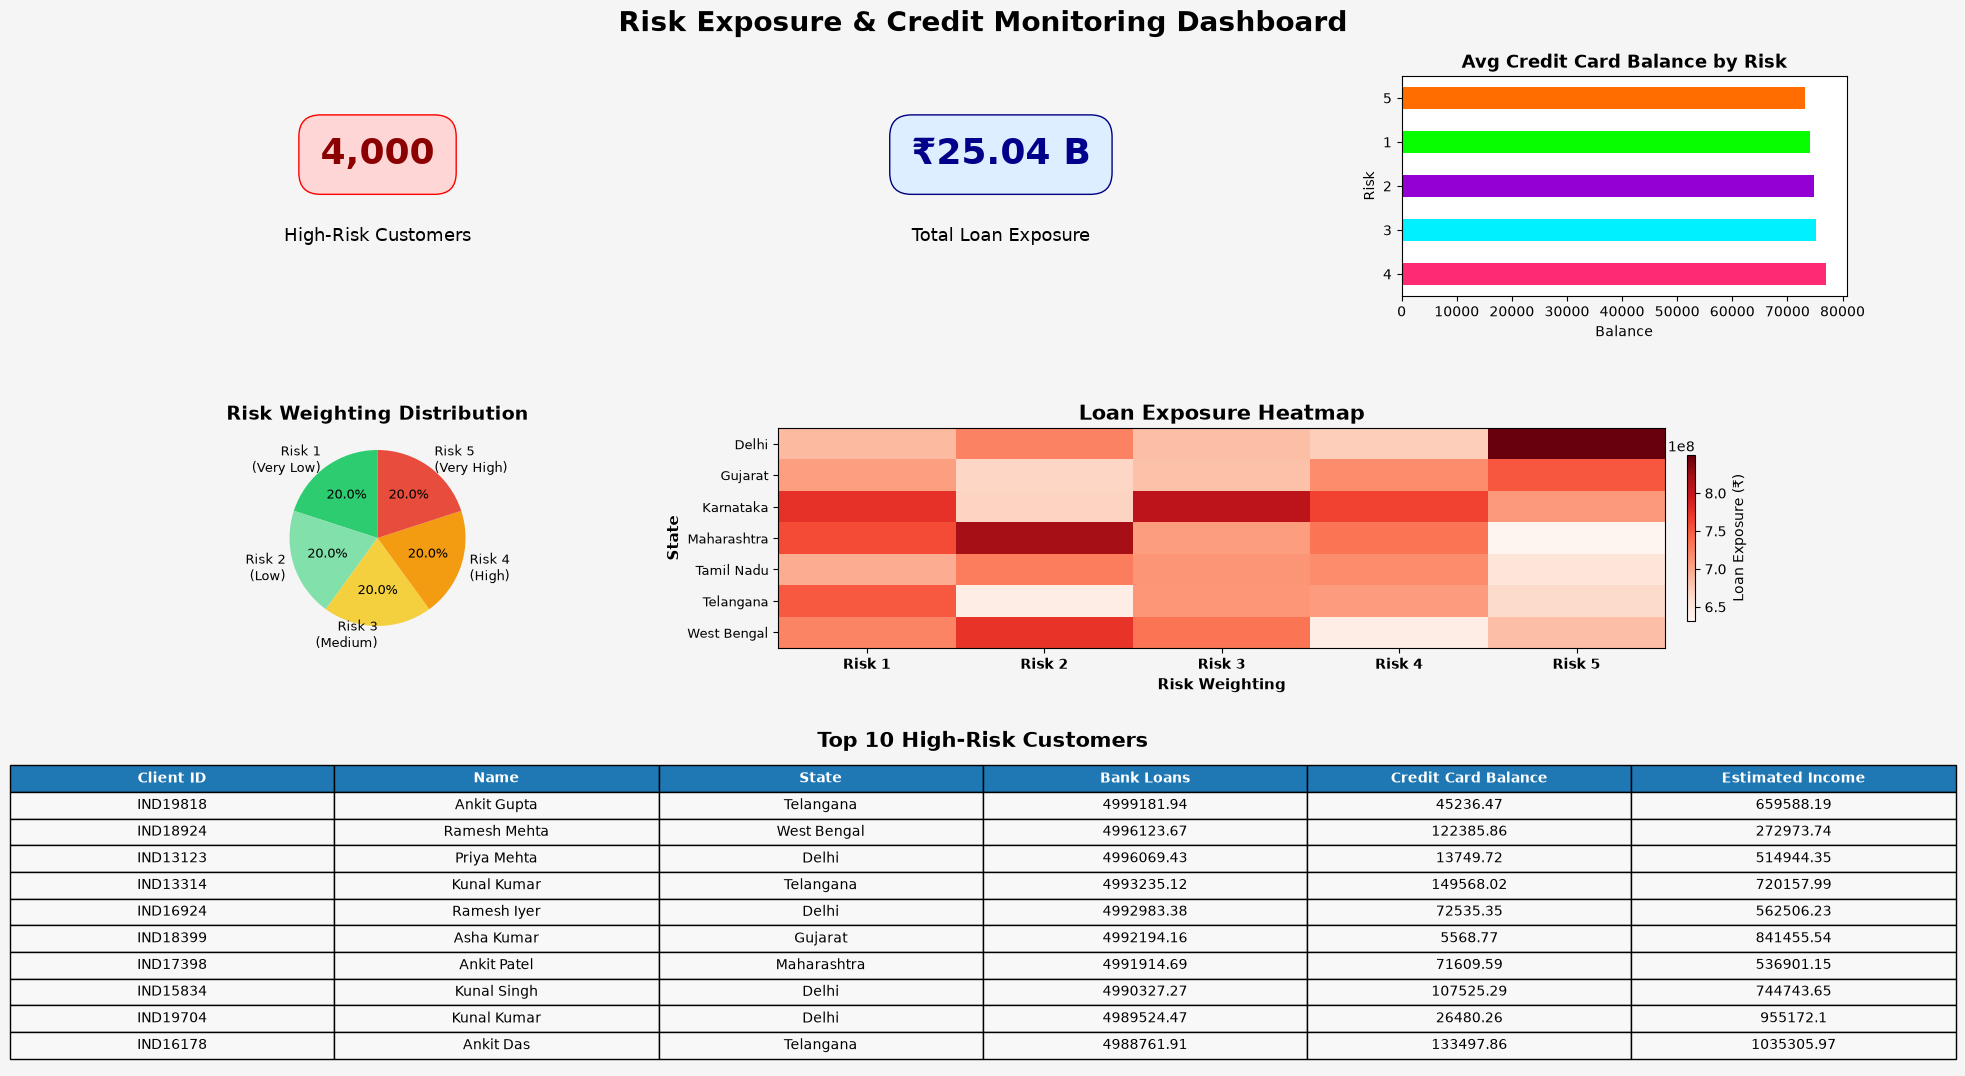

In [39]:
df["Risk Weighting"] = pd.to_numeric(df["Risk Weighting"], errors="coerce")
high_risk = df[df["Risk Weighting"] >= 4]
high_risk_count = len(high_risk)

total_loan_exposure = df["Bank Loans"].sum()

avg_cc_balance = (
    df.groupby("Risk Weighting")["Credit Card Balance"]
      .mean()
      .sort_values(ascending=False)
)
fig = plt.figure(figsize=(18,11), facecolor="#F5F5F5")
fig.suptitle(
    "Risk Exposure & Credit Monitoring Dashboard",
    fontsize=20,
    fontweight="bold"
)
ax1 = plt.subplot2grid((3,3),(0,0))
ax1.axis("off")
ax1.text(
    0.5,
    0.60,
    f"{high_risk_count:,}",
    fontsize=26,
    fontweight="bold",
    ha="center",
    color="darkred",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#FFD6D6",
        edgecolor="red"
    )
)
ax1.text(
    0.5,
    0.25,
    "High-Risk Customers",
    fontsize=13,
    ha="center"
)
ax2 = plt.subplot2grid((3,3),(0,1))
ax2.axis("off")
ax2.text(
    0.5,
    0.60,
    f"₹{total_loan_exposure/1e9:.2f} B",
    fontsize=26,
    fontweight="bold",
    ha="center",
    color="darkblue",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#DCEEFF",
        edgecolor="navy"
    )
)

ax2.text(
    0.5,
    0.25,
    "Total Loan Exposure",
    fontsize=13,
    ha="center"
)
ax3 = plt.subplot2grid((3,3),(0,2))
avg_cc_balance.plot(
    kind="barh",
    ax=ax3,
    color=["#FF2A74","#00F0FF","#9400D3","#05FF00","#FF6C00"]
)

ax3.set_title(
    "Avg Credit Card Balance by Risk",
    fontsize=13,
    fontweight="bold"
)

ax3.set_xlabel("Balance")
ax3.set_ylabel("Risk")
ax4 = plt.subplot2grid((3,3),(1,0))
risk_count = df["Risk Weighting"].value_counts().sort_index()
risk_labels = [
    "Risk 1\n(Very Low)",
    "Risk 2\n(Low)",
    "Risk 3\n(Medium)",
    "Risk 4\n(High)",
    "Risk 5\n(Very High)"
]
colors = [
    "#2ECC71",
    "#82E0AA",
    "#F4D03F",
    "#F39C12",
    "#E74C3C"
]

ax4.pie(
    risk_count.values,
    labels=risk_labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize":9}
)

ax4.set_title(
    "Risk Weighting Distribution",
    fontsize=14,
    fontweight="bold"
)
ax5 = plt.subplot2grid((3,3), (1,1), colspan=2)
heat = df.pivot_table(
    values="Bank Loans",
    index="State",
    columns="Risk Weighting",
    aggfunc="sum",
    fill_value=0
)
img = ax5.imshow(
    heat,
    cmap="Reds",
    aspect="auto",
    interpolation="nearest"
)
ax5.set_xticks(np.arange(len(heat.columns)))
ax5.set_xticklabels(
    [f"Risk {i}" for i in heat.columns],
    fontsize=10,
    fontweight="bold"
)
ax5.set_yticks(np.arange(len(heat.index)))
ax5.set_yticklabels(
    heat.index,
    fontsize=9
)
ax5.set_xlabel(
    "Risk Weighting",
    fontsize=11,
    fontweight="bold"
)
ax5.set_ylabel(
    "State",
    fontsize=11,
    fontweight="bold"
)
ax5.set_title(
    "Loan Exposure Heatmap",
    fontsize=15,
    fontweight="bold"
)
cbar = plt.colorbar(
    img,
    ax=ax5,
    shrink=0.75,
    pad=0.02
)
cbar.set_label("Loan Exposure (₹)", fontsize=10)
ax6 = plt.axes([0.03, 0.02, 0.94, 0.28])
ax6.axis("off")
table = high_risk[
    [
        "Client ID",
        "Name",
        "State",
        "Bank Loans",
        "Credit Card Balance",
        "Estimated Income"
    ]
].sort_values(
    by="Bank Loans",
    ascending=False
).head(10)
tbl = ax6.table(
    cellText=table.values,
    colLabels=table.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15,1.6)
for (row,col), cell in tbl.get_celld().items():

    if row == 0:
        cell.set_facecolor("#1F77B4")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F8F8F8")
ax6.set_title(
    "Top 10 High-Risk Customers",
    fontsize=15,
    fontweight="bold",
    pad=8
)
plt.subplots_adjust(
    left=0.04,
    right=0.98,
    top=0.92,
    bottom=0.08,
    hspace=0.60,
    wspace=0.40
)
plt.show()


# 8.State & City Expansion Strategy Dashboard 

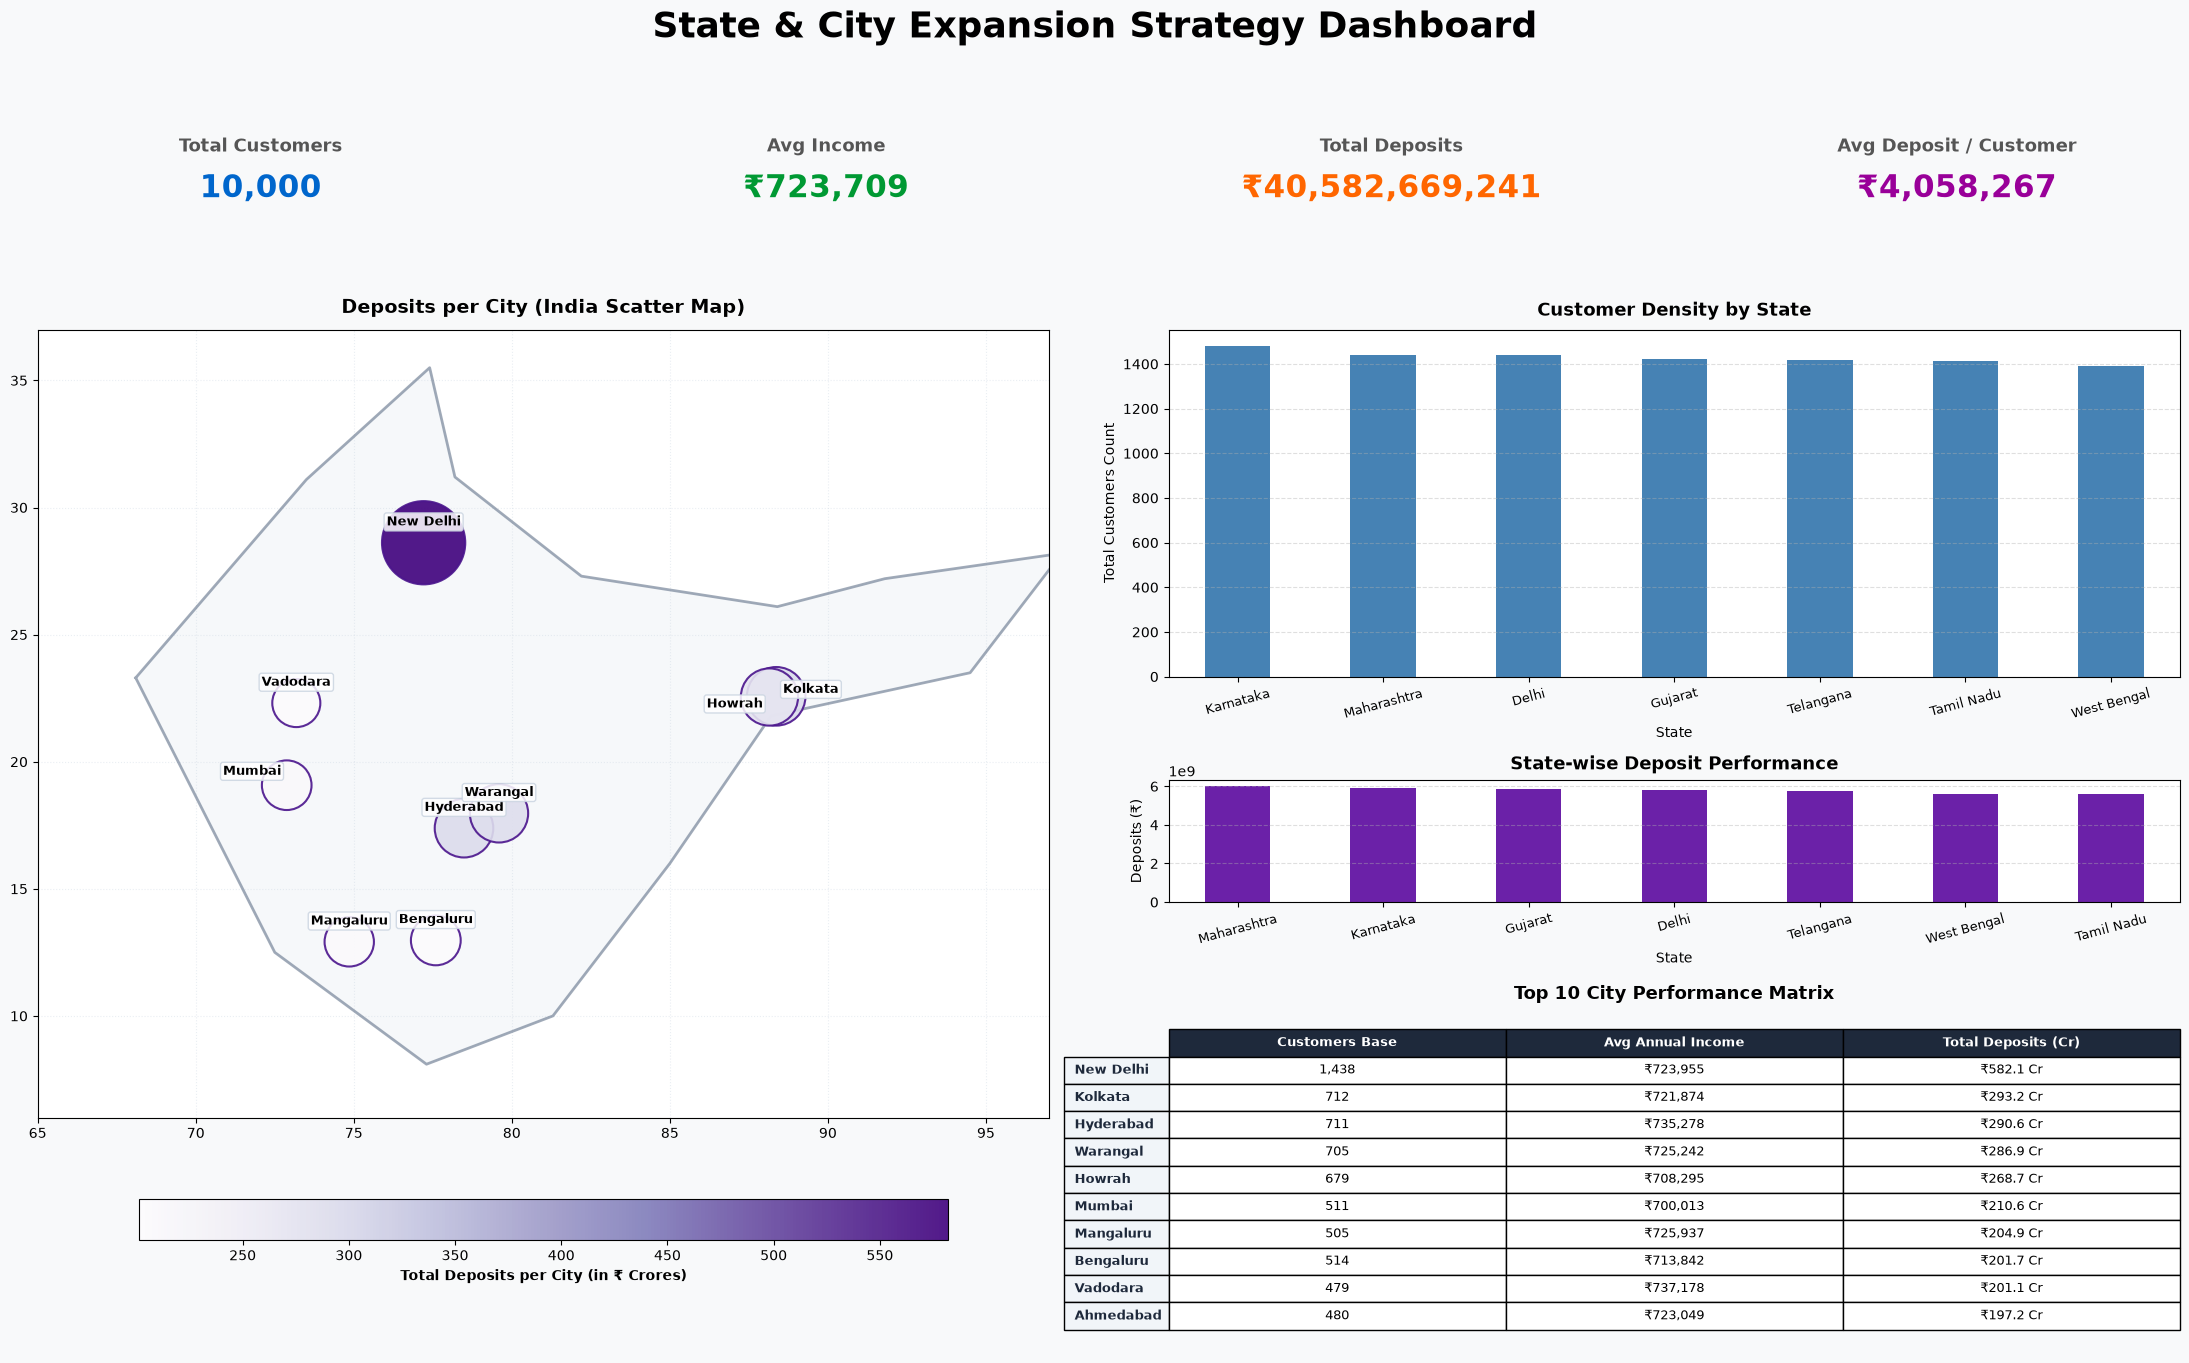

In [40]:
city_coords = {
    'New Delhi': [28.6139, 77.2090], 'Hyderabad': [17.3850, 78.4867],
    'Kolkata': [22.5726, 88.3639], 'Warangal': [17.9689, 79.5941],
    'Howrah': [22.5450, 88.1500],  
    'Mumbai': [19.0760, 72.8777],   'Bengaluru': [12.9716, 77.5946], 
    'Mangaluru': [12.9141, 74.8560], 'Vadodara': [22.3072, 73.1812], 
    'Pune': [18.5204, 73.8567]
}

india_poly_lon = [68.1, 73.5, 77.4, 78.2, 82.2, 88.4, 91.8, 97.4, 94.5, 88.2, 85.0, 81.3, 77.3, 72.5, 68.1]
india_poly_lat = [23.3, 31.1, 35.5, 31.2, 27.3, 26.1, 27.2, 28.2, 23.5, 21.8, 16.0, 10.0,  8.1, 12.5, 23.3]

total_customers = len(df)
avg_income = df["Estimated Income"].mean()
total_deposits = df["Bank Deposits"].sum()
avg_deposit_customer = df["Bank Deposits"].mean()

customer_density = df.groupby("State")["Client ID"].count().sort_values(ascending=False)
state_perf = df.groupby("State")["Bank Deposits"].sum().sort_values(ascending=False)
city_table = (
    df.groupby("City")
    .agg(
        Customers=("Client ID", "count"),
        Avg_Income=("Estimated Income", "mean"),
        Total_Deposits=("Bank Deposits", "sum")
    )
    .sort_values("Total_Deposits", ascending=False)
    .head(10)
)

scatter_data = []
formatted_table_values = []
for city, row in city_table.iterrows():
    formatted_table_values.append([
        f"{int(row['Customers']):,}",
        f"₹{int(row['Avg_Income']):,}",
        f"₹{row['Total_Deposits'] / 1e7:.1f} Cr"
    ])
    if city in city_coords:
        lat, lon = city_coords[city]
        scatter_data.append({
            'City': city, 'Latitude': lat, 'Longitude': lon,
            'Customers': row['Customers'], 'Deposits_Cr': row['Total_Deposits'] / 1e7
        })
df_scatter = pd.DataFrame(scatter_data)

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("State & City Expansion Strategy Dashboard", fontsize=26, fontweight="bold", y=0.97)

def kpi(ax, title, value, color):
    ax.axis("off")
    ax.text(0.5, 0.65, title, ha="center", va="center", fontsize=13, fontweight="bold", color="#555555")
    ax.text(0.5, 0.30, value, ha="center", va="center", fontsize=22, color=color, fontweight="bold")
    ax.set_facecolor("white")
    for s in ax.spines.values():
        s.set_visible(True); s.set_color("#E2E8F0"); s.set_linewidth(1.5)

kpi1 = plt.subplot2grid((6, 4), (0, 0))
kpi2 = plt.subplot2grid((6, 4), (0, 1))
kpi3 = plt.subplot2grid((6, 4), (0, 2))
kpi4 = plt.subplot2grid((6, 4), (0, 3))

kpi(kpi1, "Total Customers", f"{total_customers:,}", "#0066CC")
kpi(kpi2, "Avg Income", f"₹{avg_income:,.0f}", "#009933")
kpi(kpi3, "Total Deposits", f"₹{total_deposits:,.0f}", "#FF6600")
kpi(kpi4, "Avg Deposit / Customer", f"₹{avg_deposit_customer:,.0f}", "#990099")

ax_map = plt.subplot2grid((6, 4), (1, 0), rowspan=5, colspan=2)
ax_map.set_title("Deposits per City (India Scatter Map)", fontsize=14, fontweight="bold", pad=12)
ax_map.set_xlim(65, 97)
ax_map.set_ylim(6, 37)
ax_map.grid(True, linestyle=":", alpha=0.4, color="#CBD5E1")
ax_map.plot(india_poly_lon, india_poly_lat, color="#64748B", linewidth=2, alpha=0.6)
ax_map.fill(india_poly_lon, india_poly_lat, color="#E2E8F0", alpha=0.3)
sc = ax_map.scatter(
    df_scatter['Longitude'], df_scatter['Latitude'], 
    s=df_scatter['Customers'] * 2.5, 
    c=df_scatter['Deposits_Cr'], 
    cmap='Purples', alpha=0.9, edgecolors='#4A148C', linewidth=1.5, zorder=3
)
for idx, row in df_scatter.iterrows():
    
    if row['City'] == 'Kolkata': offset = (25, 5)
    elif row['City'] == 'Howrah': offset = (-25, -5)
    elif row['City'] == 'Pune': offset = (-20, -12)
    elif row['City'] == 'Mumbai': offset = (-25, 10)
    else: offset = (0, 15)
        
    ax_map.annotate(
        row['City'], (row['Longitude'], row['Latitude']),
        textcoords="offset points", xytext=offset, ha='center', va='center',
        fontsize=9, fontweight='bold', zorder=4,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", edgecolor="#CBD5E1", alpha=0.85)
    )

cbar = plt.colorbar(sc, ax=ax_map, orientation='horizontal', pad=0.08, shrink=0.8)
cbar.set_label('Total Deposits per City (in ₹ Crores)', fontsize=10, weight='bold')

ax_density = plt.subplot2grid((6, 4), (1, 2), rowspan=2, colspan=2)
customer_density.plot(kind="bar", ax=ax_density, color="steelblue", width=0.45)
ax_density.set_title("Customer Density by State", fontsize=13, fontweight="bold", pad=10)
ax_density.set_ylabel("Total Customers Count")
ax_density.tick_params(axis="x", rotation=15, labelsize=9)
ax_density.grid(axis='y', linestyle='--', alpha=0.4)

ax_bar = plt.subplot2grid((6, 4), (3, 2), rowspan=1, colspan=2)
state_perf.plot(kind="bar", ax=ax_bar, color="#6B21A8", width=0.45)
ax_bar.set_title("State-wise Deposit Performance", fontsize=13, fontweight="bold", pad=8)
ax_bar.set_ylabel("Deposits (₹)")
ax_bar.tick_params(axis="x", rotation=15, labelsize=9)
ax_bar.grid(axis='y', linestyle='--', alpha=0.4)

ax_tbl = plt.subplot2grid((6, 4), (4, 2), rowspan=2, colspan=2)
ax_tbl.axis("off")

table = ax_tbl.table(
    cellText=formatted_table_values,
    colLabels=["Customers Base", "Avg Annual Income", "Total Deposits (Cr)"],
    rowLabels=city_table.index,
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1E293B')
    elif col == -1:
        cell.set_text_props(weight='bold', color='#1E293B')
        cell.set_facecolor('#F1F5F9')

ax_tbl.set_title("Top 10 City Performance Matrix", fontsize=13, fontweight="bold", pad=5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# 9. Customer Demographics & Behavior Dashboard 

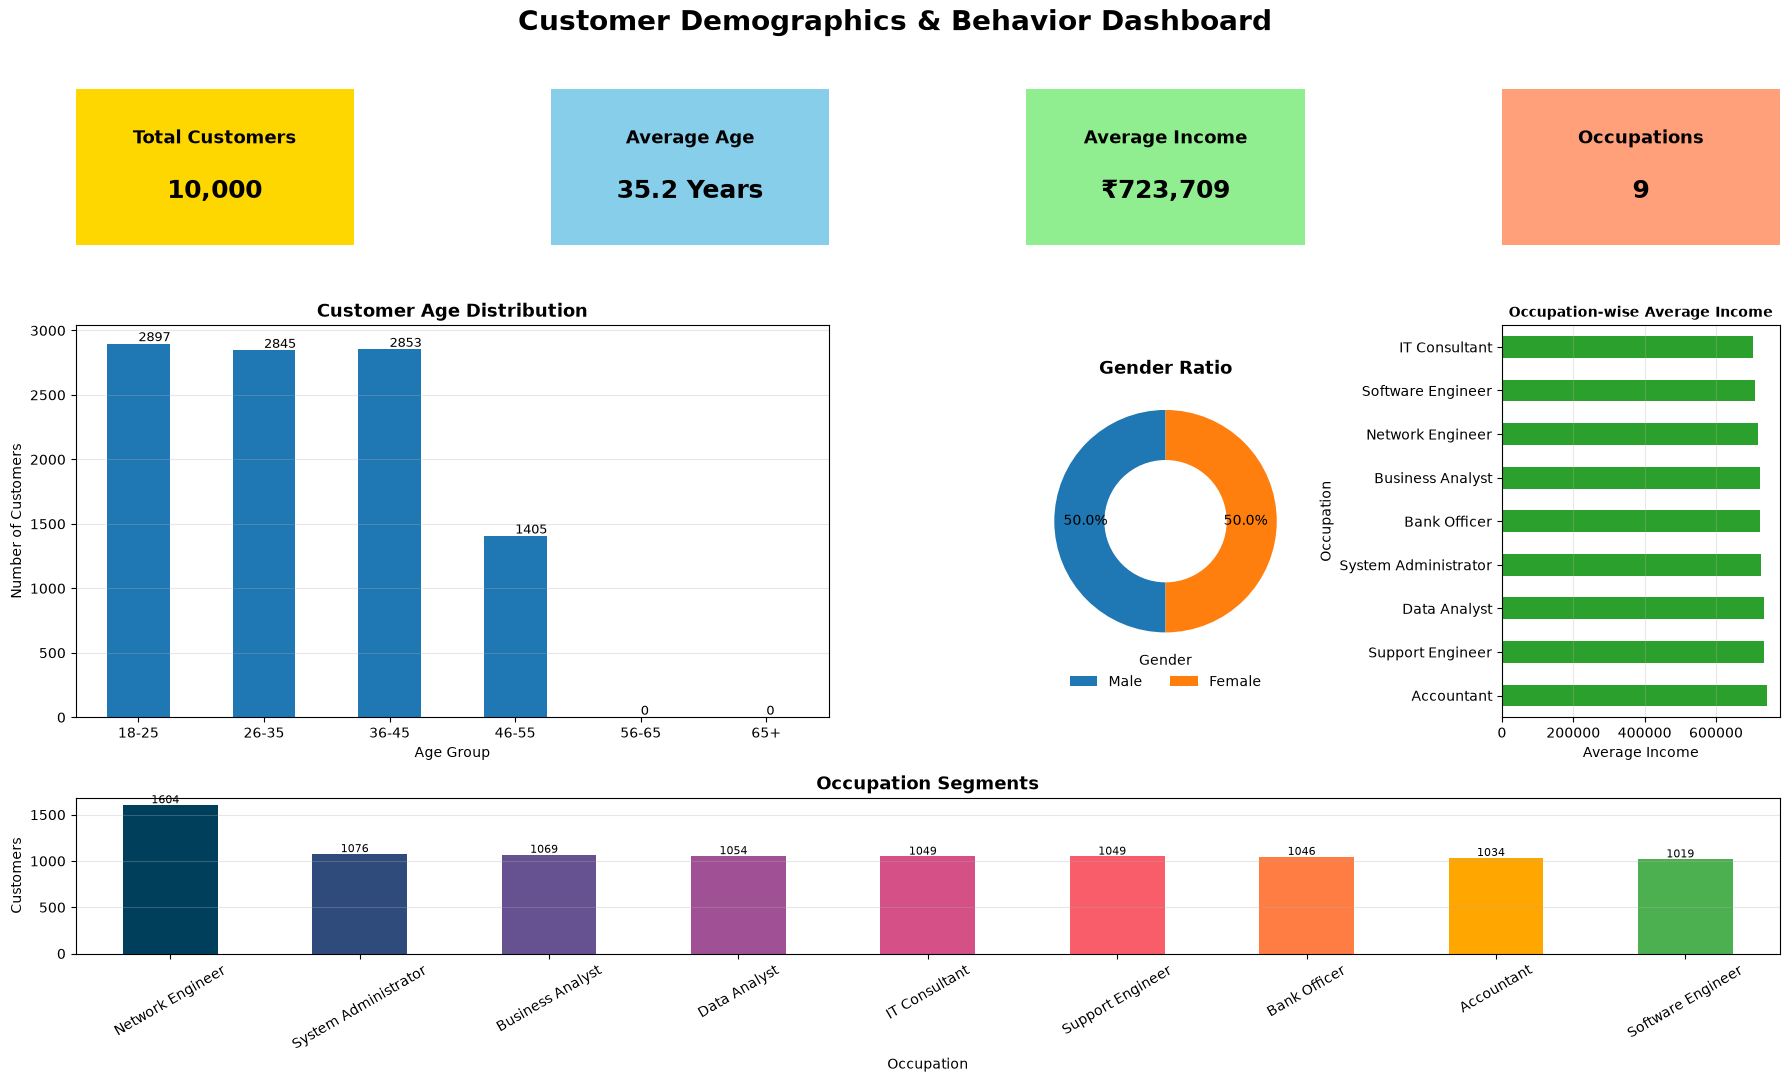

In [41]:
gender_map = {
    1: "Male",
    2: "Female"
}
df["Gender"] = df["GenderId"].map(gender_map)
bins = [18,25,35,45,55,65,100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

total_customers = df["Client ID"].nunique()
avg_age = df["Age"].mean()
avg_income = df["Estimated Income"].mean()
unique_occupations = df["Occupation"].nunique()
age_distribution = (
    df["Age Group"]
    .value_counts()
    .sort_index()
)
gender_ratio = (
    df["Gender"]
    .value_counts()
)
occupation_income = (
    df.groupby("Occupation")["Estimated Income"]
    .mean()
    .sort_values(ascending=False)
)
occupation_count = (
    df["Occupation"]
    .value_counts()
)
fig = plt.figure(figsize=(18,11))

fig.suptitle(
    "Customer Demographics & Behavior Dashboard",
    fontsize=20,
    fontweight="bold"
)
def kpi(ax, title, value, color):

    ax.axis("off")

    box = FancyBboxPatch(
        (0,0),
        1,
        1,
        boxstyle="round,pad=0.04",
        facecolor=color,
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(
        0.5,
        0.65,
        title,
        fontsize=13,
        ha="center",
        weight="bold"
    )
    ax.text(
        0.5,
        0.30,
        value,
        fontsize=18,
        ha="center",
        weight="bold"
    )
k1 = plt.subplot2grid((4,4),(0,0))
kpi(k1,"Total Customers",f"{total_customers:,}","#FFD700")

k2 = plt.subplot2grid((4,4),(0,1))
kpi(k2,"Average Age",f"{avg_age:.1f} Years","#87CEEB")

k3 = plt.subplot2grid((4,4),(0,2))
kpi(k3,"Average Income",f"₹{avg_income:,.0f}","#90EE90")

k4 = plt.subplot2grid((4,4),(0,3))
kpi(k4,"Occupations",unique_occupations,"#FFA07A")

ax1 = plt.subplot2grid((4,4),(1,0),colspan=2,rowspan=2)
age_distribution.plot(
    kind="bar",
    ax=ax1,
    color="#1F77B4"
)
ax1.set_title(
    "Customer Age Distribution",
    fontsize=13,
    fontweight="bold"
)
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Number of Customers")
ax1.tick_params(axis='x',rotation=0)
ax1.grid(axis="y",alpha=.3)
for p in ax1.patches:
    ax1.annotate(
        int(p.get_height()),
        (p.get_x()+0.25,p.get_height()+20),
        fontsize=9
    )
ax2 = plt.subplot2grid((4,4),(1,2),rowspan=2)
wedges, texts, autotexts = ax2.pie(
    gender_ratio,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.45),
    pctdistance=0.72
)
ax2.legend(
    wedges,
    gender_ratio.index,
    title="Gender",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)
ax2.set_title(
    "Gender Ratio",
    fontsize=13,
    fontweight="bold"
)
ax3 = plt.subplot2grid((4,4),(1,3),rowspan=2)
occupation_income.plot(
    kind="barh",
    ax=ax3,
    color="#2CA02C"
)
ax3.set_title(
    "Occupation-wise Average Income",
    fontsize=10,
    fontweight="bold"
)
ax3.set_xlabel("Average Income")
ax3.set_ylabel("Occupation")
ax3.grid(axis="x",alpha=.3)
ax4 = plt.subplot2grid((4,4),(3,0),colspan=4)

occupation_count.plot(
    kind="bar",
    ax=ax4,
    color = [
    "#003F5C",
    "#2F4B7C",
    "#665191",
    "#A05195",
    "#D45087",
    "#F95D6A",
    "#FF7C43",
    "#FFA600",
    "#4CAF50"
]
)
ax4.set_title(
    "Occupation Segments",
    fontsize=13,
    fontweight="bold"
)
ax4.set_xlabel("Occupation")
ax4.set_ylabel("Customers")
ax4.tick_params(axis="x",rotation=30)
ax4.grid(axis="y",alpha=.3)
for p in ax4.patches:
    ax4.annotate(
        int(p.get_height()),
        (p.get_x()+0.15,p.get_height()+20),
        fontsize=8
    )
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# 10.Executive Banking Overview Dashboard (CEO View) 

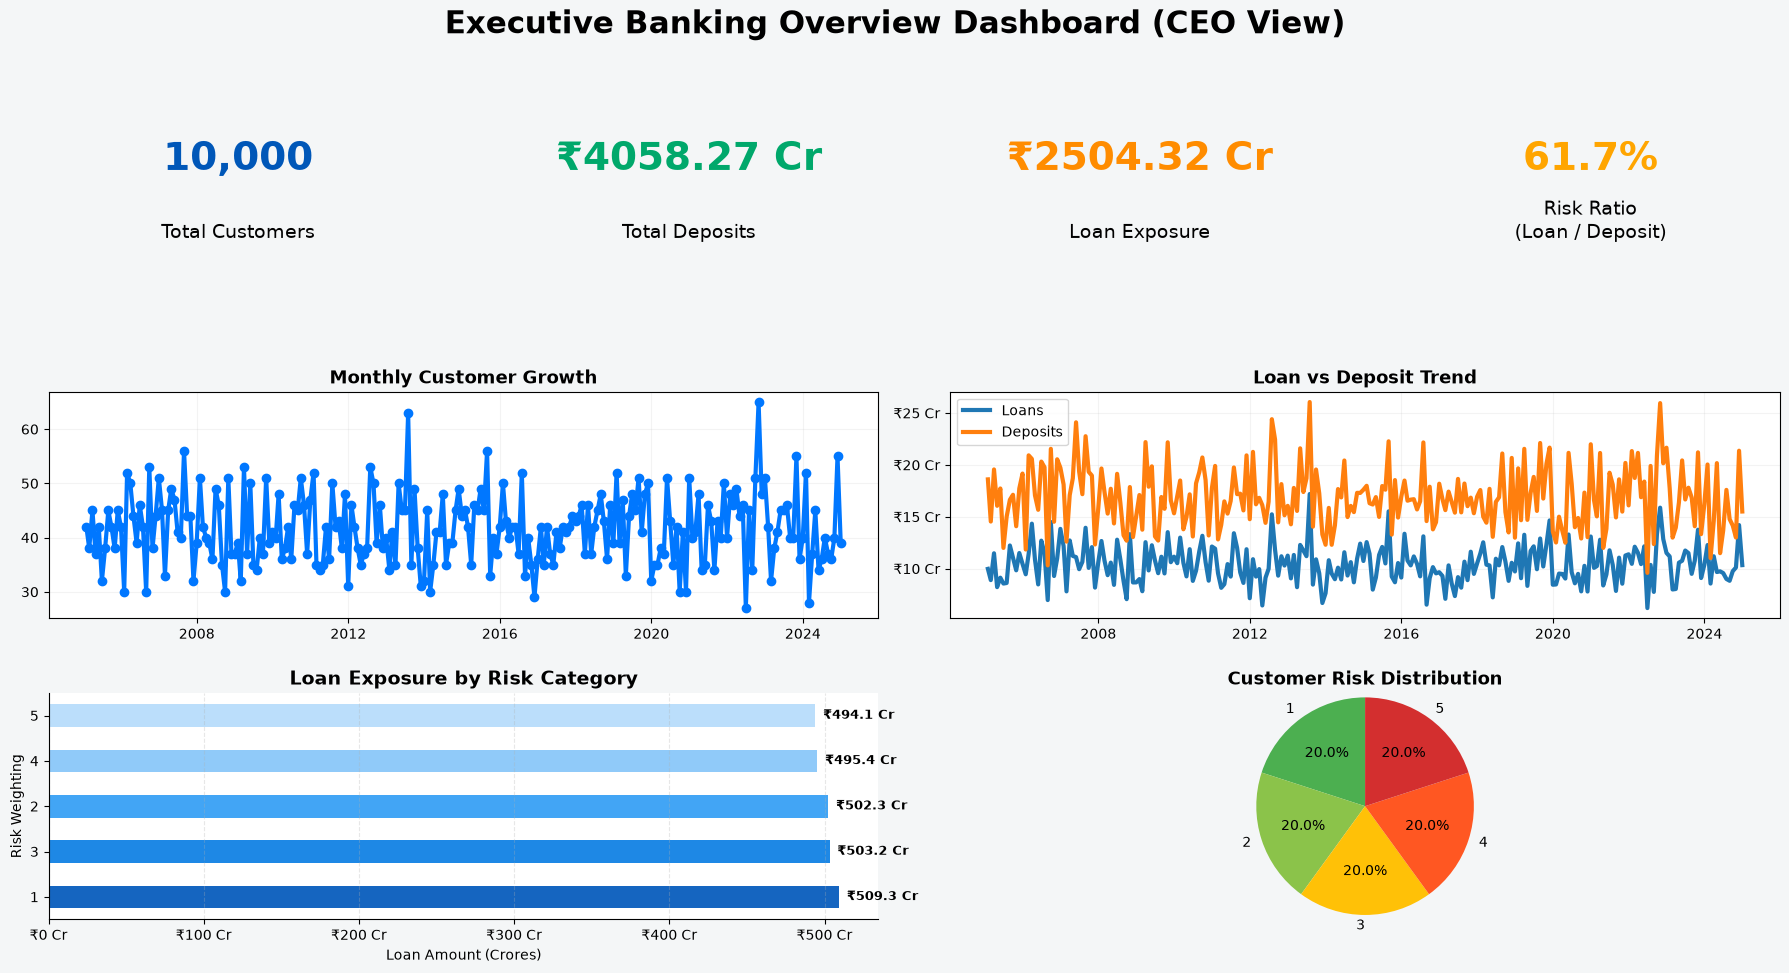

In [43]:
from matplotlib.ticker import FuncFormatter
df["Joined Bank"] = pd.to_datetime(
    df["Joined Bank"],
    format="%d-%m-%Y"
)
total_customers = df["Client ID"].nunique()
total_deposits = df["Bank Deposits"].sum()
loan_exposure = df["Bank Loans"].sum()
risk_ratio = (
    df["Bank Loans"].sum()
    /
    df["Bank Deposits"].sum()
) * 100
customer_growth = (
    df.set_index("Joined Bank")
      .resample("ME")["Client ID"]
      .count()
)
monthly_data = (
    df.set_index("Joined Bank")
      .resample("ME")[["Bank Loans","Bank Deposits"]]
      .sum()
)
loan_risk = (
    df.groupby("Risk Weighting")["Bank Loans"]
      .sum()
      .sort_values()
)
risk_count = (
    df["Risk Weighting"]
      .value_counts()
)
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor("#F4F6F7")

plt.suptitle(
    "Executive Banking Overview Dashboard (CEO View)",
    fontsize=22,
    fontweight="bold"
)
ax1 = plt.subplot2grid((3,4),(0,0))
ax1.axis("off")
ax1.text(
    0.5,0.65,
    f"{total_customers:,}",
    fontsize=28,
    fontweight="bold",
    ha="center",
    color="#0057B8"
)
ax1.text(
    0.5,0.35,
    "Total Customers",
    fontsize=14,
    ha="center"
)
ax2 = plt.subplot2grid((3,4),(0,1))
ax2.axis("off")
ax2.text(
    0.5,0.65,
    f"₹{total_deposits/1e7:.2f} Cr",
    fontsize=28,
    fontweight="bold",
    ha="center",
    color="#00A86B"
)

ax2.text(
    0.5,0.35,
    "Total Deposits",
    fontsize=14,
    ha="center"
)

ax3 = plt.subplot2grid((3,4),(0,2))
ax3.axis("off")
ax3.text(
    0.5,0.65,
    f"₹{loan_exposure/1e7:.2f} Cr",
    fontsize=28,
    fontweight="bold",
    ha="center",
    color="#FF8C00"
)
ax3.text(
    0.5,0.35,
    "Loan Exposure",
    fontsize=14,
    ha="center"
)
ax4 = plt.subplot2grid((3,4),(0,3))
ax4.axis("off")

color = "green"

if risk_ratio > 80:
    color = "red"
elif risk_ratio > 60:
    color = "orange"
ax4.text(
    0.5,0.65,
    f"{risk_ratio:.1f}%",
    fontsize=28,
    fontweight="bold",
    ha="center",
    color=color
)
ax4.text(
    0.5,0.35,
    "Risk Ratio\n(Loan / Deposit)",
    fontsize=14,
    ha="center"
)
ax5 = plt.subplot2grid((3,4),(1,0),colspan=2)
ax5.plot(
    customer_growth.index,
    customer_growth.values,
    linewidth=3,
    marker="o",
    color="#0077FF"
)

ax5.set_title(
    "Monthly Customer Growth",
    fontsize=13,
    fontweight="bold"
)

ax5.grid(alpha=.15)
ax6 = plt.subplot2grid((3,4),(1,2),colspan=2)
ax6.plot(
    monthly_data.index,
    monthly_data["Bank Loans"],
    linewidth=3,
    label="Loans"
)
ax6.plot(
    monthly_data.index,
    monthly_data["Bank Deposits"],
    linewidth=3,
    label="Deposits"
)

ax6.set_title(
    "Loan vs Deposit Trend",
    fontsize=13,
    fontweight="bold"
)
ax6.legend()
ax6.grid(alpha=.15)
loan_risk = (
    df.groupby("Risk Weighting")["Bank Loans"]
      .sum()
      .sort_values(ascending=False)
)
colors = [
    "#1565C0",
    "#1E88E5",
    "#42A5F5",
    "#90CAF9",
    "#BBDEFB"
]
ax7 = plt.subplot2grid((3,4), (2,0), colspan=2)

loan_risk.plot(
    kind="barh",
    ax=ax7,
    color=colors
)
ax7.set_title(
    "Loan Exposure by Risk Category",
    fontsize=14,
    fontweight="bold"
)
ax7.set_xlabel("Loan Amount (Crores)")
ax7.set_ylabel("Risk Weighting")
ax7.grid(axis="x", linestyle="--", alpha=0.3)
ax7.spines["top"].set_visible(False)
ax7.spines["right"].set_visible(False)
ax7.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e7:.0f} Cr")
)

for i, value in enumerate(loan_risk.values):
    ax7.text(
        value + value*0.01,
        i,
        f"₹{value/1e7:.1f} Cr",
        va="center",
        fontsize=9,
        fontweight="bold"
    )
ax8 = plt.subplot2grid((3,4),(2,2),colspan=2)
ax8.set_position([0.66,0.07,0.30,0.28])
ax8.pie(
    risk_count.values,
    radius=1.2,
    labels=risk_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#4CAF50",
        "#8BC34A",
        "#FFC107",
        "#FF5722",
        "#D32F2F"
    ]
)
ax8.set_title(
    "Customer Risk Distribution",
    fontsize=13,
    fontweight="bold"
)
ax6.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'₹{x/1e7:.0f} Cr')
)
ax7.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'₹{x/1e7:.0f} Cr')
)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# 11.Data Quality Monitoring Dashboard 

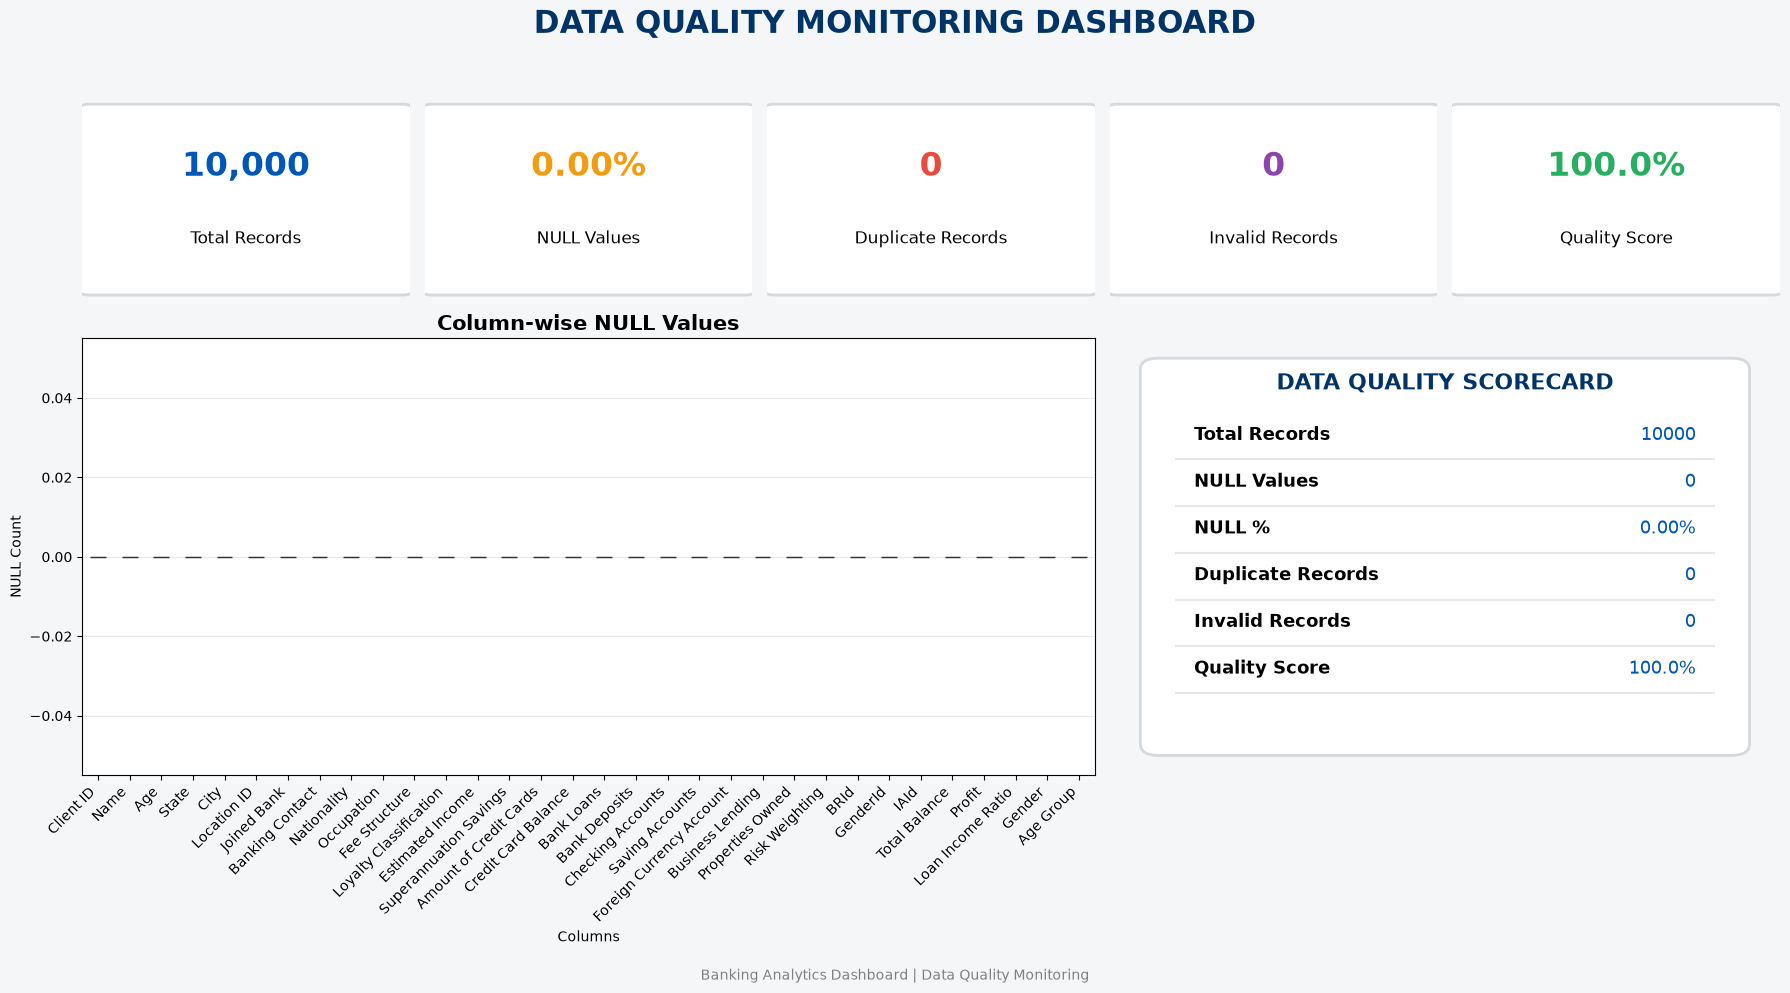

In [44]:
total_records = len(df)
total_cells = df.shape[0] * df.shape[1]
null_values = df.isnull().sum()
total_nulls = null_values.sum()
null_percentage = (total_nulls / total_cells) * 100
duplicate_count = df.duplicated().sum()

invalid_records = df[
    (df["Bank Deposits"] < 0) |
    (df["Bank Loans"] < 0) |
    (df["Credit Card Balance"] < 0)
].shape[0]
quality_score = (
    100
    - null_percentage
    - (duplicate_count / total_records * 100)
    - (invalid_records / total_records * 100)
)
quality_score = max(0, round(quality_score,2))
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor("#F4F6F7")
fig.suptitle(
    "DATA QUALITY MONITORING DASHBOARD",
    fontsize=22,
    fontweight="bold",
    color="#003366"
)
def kpi_card(ax, value, label, color):

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    ax.axis("off")

    box = FancyBboxPatch(
        (0.02,0.05),
        0.96,
        0.90,
        boxstyle="round,pad=0.03",
        fc="white",
        ec="#D5D8DC",
        linewidth=2
    )
    ax.add_patch(box)
    ax.text(
        0.5,
        0.62,
        value,
        fontsize=24,
        fontweight="bold",
        ha="center",
        color=color
    )
    ax.text(
        0.5,
        0.28,
        label,
        fontsize=12,
        ha="center"
    )
ax1 = plt.subplot2grid((3,5),(0,0))
kpi_card(ax1,f"{total_records:,}","Total Records","#0057B8")

ax2 = plt.subplot2grid((3,5),(0,1))
kpi_card(ax2,f"{null_percentage:.2f}%","NULL Values","#F39C12")

ax3 = plt.subplot2grid((3,5),(0,2))
kpi_card(ax3,f"{duplicate_count:,}","Duplicate Records","#E74C3C")

ax4 = plt.subplot2grid((3,5),(0,3))
kpi_card(ax4,f"{invalid_records:,}","Invalid Records","#8E44AD")

ax5 = plt.subplot2grid((3,5),(0,4))
kpi_card(ax5,f"{quality_score:.1f}%","Quality Score","#27AE60")
ax6 = plt.subplot2grid((3,5),(1,0),colspan=3,rowspan=2)
null_values.sort_values(ascending=False).plot(
    kind="bar",
    ax=ax6,
    color="#3498DB",
    edgecolor="black"
)
ax6.set_title(
    "Column-wise NULL Values",
    fontsize=15,
    fontweight="bold"
)
ax6.set_xlabel("Columns")
ax6.set_ylabel("NULL Count")
plt.setp(
    ax6.get_xticklabels(),
    rotation=45,
    ha="right"
)
ax6.grid(axis="y",alpha=0.3)
ax7 = plt.subplot2grid((3,5),(1,3),colspan=2,rowspan=2)
ax7.axis("off")

score_box = FancyBboxPatch(
    (0.02,0.02),
    0.96,
    0.96,
    boxstyle="round,pad=0.03",
    fc="white",
    ec="#D5D8DC",
    linewidth=2
)
ax7.add_patch(score_box)
ax7.text(
    0.5,
    0.93,
    "DATA QUALITY SCORECARD",
    fontsize=16,
    fontweight="bold",
    ha="center",
    color="#003366"
)
metrics = [
    ("Total Records", total_records),
    ("NULL Values", total_nulls),
    ("NULL %", f"{null_percentage:.2f}%"),
    ("Duplicate Records", duplicate_count),
    ("Invalid Records", invalid_records),
    ("Quality Score", f"{quality_score:.1f}%")
]

y = 0.80
for metric,value in metrics:
    ax7.text(
        0.08,
        y,
        metric,
        fontsize=13,
        fontweight="bold"
    )

    ax7.text(
        0.92,
        y,
        str(value),
        fontsize=13,
        ha="right",
        color="#0057B8"
    )

    ax7.plot(
        [0.05,0.95],
        [y-0.05,y-0.05],
        color="#E5E7E9"
    )

    y -= 0.12
plt.figtext(
    0.5,
    0.01,
    "Banking Analytics Dashboard | Data Quality Monitoring",
    ha="center",
    fontsize=10,
    color="gray"
)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


# 12. Gender-based Financial Behavior Analysis 

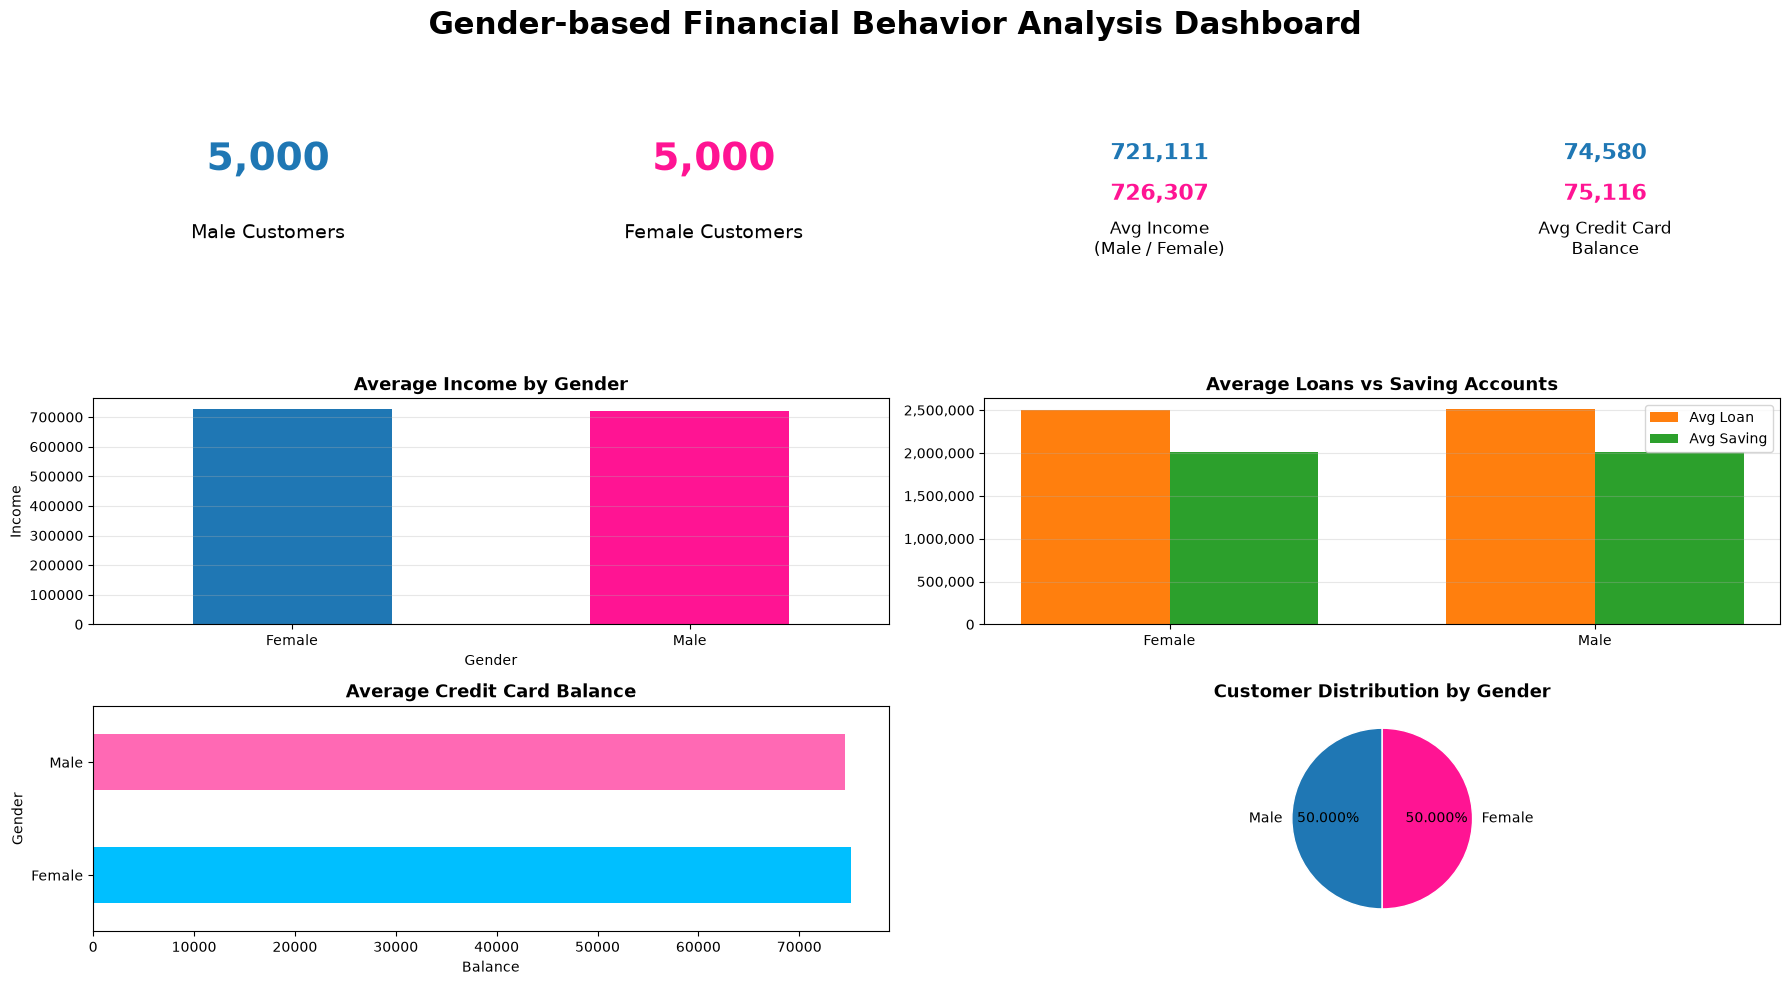

In [45]:
from matplotlib.ticker import StrMethodFormatter
gender_map = {1: "Male", 2: "Female"}
df["Gender"] = df["GenderId"].map(gender_map)
male_customers = (df["Gender"] == "Male").sum()
female_customers = (df["Gender"] == "Female").sum()
avg_income = df.groupby("Gender")["Estimated Income"].mean()
avg_loan = df.groupby("Gender")["Bank Loans"].mean()
avg_saving = df.groupby("Gender")["Saving Accounts"].mean()
avg_cc_balance = df.groupby("Gender")["Credit Card Balance"].mean()

plt.figure(figsize=(18,10))
plt.suptitle(
    "Gender-based Financial Behavior Analysis Dashboard",
    fontsize=22,
    fontweight="bold"
)
ax1 = plt.subplot2grid((3,4),(0,0))
ax1.axis("off")

ax1.text(
    0.5,0.65,
    f"{male_customers:,}",
    fontsize=28,
    fontweight="bold",
    color="#1F77B4",
    ha="center"
)

ax1.text(
    0.5,0.35,
    "Male Customers",
    fontsize=14,
    ha="center"
)
ax2 = plt.subplot2grid((3,4),(0,1))
ax2.axis("off")

ax2.text(
    0.5,0.65,
    f"{female_customers:,}",
    fontsize=28,
    fontweight="bold",
    color="#FF1493",
    ha="center"
)

ax2.text(
    0.5,0.35,
    "Female Customers",
    fontsize=14,
    ha="center"
)

ax3 = plt.subplot2grid((3,4),(0,2))
ax3.axis("off")

ax3.text(
    0.5,0.70,
    f"{avg_income['Male']:,.0f}",
    fontsize=16,
    fontweight="bold",
    color="#1F77B4",
    ha="center"
)

ax3.text(
    0.5,0.52,
    f"{avg_income['Female']:,.0f}",
    fontsize=16,
    fontweight="bold",
    color="#FF1493",
    ha="center"
)

ax3.text(
    0.5,0.28,
    "Avg Income\n(Male / Female)",
    fontsize=12,
    ha="center"
)
ax4 = plt.subplot2grid((3,4),(0,3))
ax4.axis("off")

ax4.text(
    0.5,0.70,
    f"{avg_cc_balance['Male']:,.0f}",
    fontsize=16,
    fontweight="bold",
    color="#1F77B4",
    ha="center"
)

ax4.text(
    0.5,0.52,
    f"{avg_cc_balance['Female']:,.0f}",
    fontsize=16,
    fontweight="bold",
    color="#FF1493",
    ha="center"
)

ax4.text(
    0.5,0.28,
    "Avg Credit Card\nBalance",
    fontsize=12,
    ha="center"
)
ax5 = plt.subplot2grid((3,4),(1,0),colspan=2)

avg_income.plot(
    kind="bar",
    ax=ax5,
    color=["#1F77B4","#FF1493"]
)

ax5.set_title(
    "Average Income by Gender",
    fontsize=13,
    fontweight="bold"
)

ax5.set_ylabel("Income")
ax5.set_xlabel("Gender")
ax5.tick_params(axis='x', rotation=0)
ax5.grid(axis="y",alpha=0.3)

ax6 = plt.subplot2grid((3,4),(1,2),colspan=2)
x = np.arange(len(avg_loan.index))
width = 0.35

ax6.bar(
    x-width/2,
    avg_loan.values,
    width,
    label="Avg Loan",
    color="#FF7F0E"
)

ax6.bar(
    x+width/2,
    avg_saving.values,
    width,
    label="Avg Saving",
    color="#2CA02C"
)

ax6.set_xticks(x)
ax6.set_xticklabels(avg_loan.index)
ax6.set_title(
    "Average Loans vs Saving Accounts",
    fontsize=13,
    fontweight="bold"
)
ax6.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax6.legend()
ax6.grid(axis="y",alpha=0.3)
ax7 = plt.subplot2grid((3,4),(2,0),colspan=2)
avg_cc_balance.plot(
    kind="barh",
    ax=ax7,
    color=["#00BFFF","#FF69B4"]
)
ax7.set_title(
    "Average Credit Card Balance",
    fontsize=13,
    fontweight="bold"
)
ax7.set_xlabel("Balance")
ax7.set_ylabel("Gender")

ax8 = plt.subplot2grid((3,4),(2,2),colspan=2)
gender_count = df["Gender"].value_counts()
ax8.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.3f%%",
    startangle=90,
    colors=["#1F77B4","#FF1493"],
    wedgeprops={"edgecolor":"white"}
)
ax8.set_title(
    "Customer Distribution by Gender",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
